**Module 1**

---

**Activity 1**

## (a) Maximum Likelihood Estimate

$$L(\theta) = \binom{N}{k} \theta^k (1-\theta)^{N-k}$$

$$\log L(\theta) = \log\binom{N}{k} + k\log\theta + (N-k)\log(1-\theta)$$

$$\frac{d}{d\theta} \log L = \frac{k}{\theta} - \frac{N-k}{1-\theta} = 0$$

$$\boxed{\hat{\theta}_{MLE} = \frac{k}{N}}$$

Confirming this is a maximum:

$$\frac{d^2}{d\theta^2} \log L = -\frac{k}{\theta^2} - \frac{N-k}{(1-\theta)^2} < 0 $$

## (b, c) Numerical likelihood scan & Uncertainty from likelihood curvature


MLE: θ̂ = 0.65
Lower bound: θ_low = 0.5726
Upper bound: θ_high = 0.7225
1σ interval: (0.5726,  0.7225)


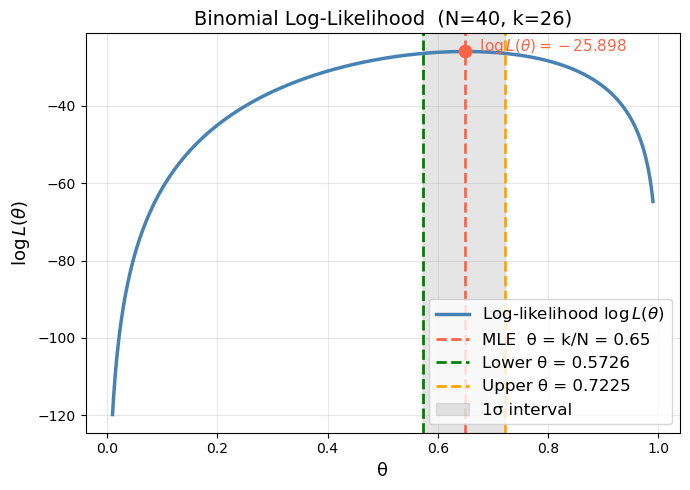

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import time

N, k = 40, 26

# Grid of theta values
theta = np.linspace(0.01, 0.99, 500)

# Log-likelihood (dropping constant binomial coefficient)
log_lik = k * np.log(theta) + (N - k) * np.log(1 - theta)

# MLE
theta_mle = k / N
ll_mle = k * np.log(theta_mle) + (N - k) * np.log(1 - theta_mle)


# 1-sigma threshold
threshold = ll_mle - 0.5

# Find bounds numerically using root finding: ℓ(θ) - threshold = 0
def ll(t):
    return k * np.log(t) + (N - k) * np.log(1 - t)

theta_lower = brentq(lambda t: ll(t) - threshold, 0.01, theta_mle)
theta_upper = brentq(lambda t: ll(t) - threshold, theta_mle, 0.99)

print(f"MLE: θ̂ = {theta_mle}")
print(f"Lower bound: θ_low = {theta_lower:.4f}")
print(f"Upper bound: θ_high = {theta_upper:.4f}")
print(f"1σ interval: ({theta_lower:.4f},  {theta_upper:.4f})")

# Plot
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(theta, log_lik, lw=2.5, color='steelblue', label='Log-likelihood $\log L(θ)$')
ax.axvline(theta_mle, color='tomato', ls='--', lw=2, label=f'MLE  θ = k/N = {theta_mle}')
ax.axvline(theta_lower, color='green',  ls='--', lw=2, label=f'Lower θ = {theta_lower:.4f}')
ax.axvline(theta_upper, color='orange', ls='--', lw=2, label=f'Upper θ = {theta_upper:.4f}')
ax.scatter([theta_mle], [ll_mle], color='tomato', zorder=5, s=80)
ax.annotate(f'$ \quad \log L(θ) = {ll_mle:.3f}$',
            xy=(theta_mle, ll_mle), fontsize=11, color='tomato')

# Shade the confidence interval
mask = (theta >= theta_lower) & (theta <= theta_upper)
ax.axvspan(theta_lower, theta_upper, alpha=0.2, color='grey', label='1σ interval')

ax.set_xlabel('θ', fontsize=13)
ax.set_ylabel('$\log L(θ)$', fontsize=13)
ax.set_title(f'Binomial Log-Likelihood  (N={N}, k={k})', fontsize=14)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## (d) Width of the Likelihood Represents Parameter Uncertainty

The log-likelihood tells you how compatible each value of $\theta$ is with your data. The sample size $N$ controls the width. The second derivative of the log-likelihood (its curvature) is:

$$\frac{d^2\ell}{d\theta^2} = -\frac{k}{\theta^2} - \frac{N-k}{(1-\theta)^2}$$

At the MLE $\hat{\theta} = k/N$, this is proportional to $-N$:

- **Large $N$** $\Rightarrow$ large negative curvature $\Rightarrow$ sharp narrow peak $\Rightarrow$ small uncertainty
- **Small $N$** $\Rightarrow$ small negative curvature $\Rightarrow$ flat wide peak $\Rightarrow$ large uncertainty

This is why collecting more data reduces uncertainty.

The 1$\sigma$ interval makes this concrete. The threshold $\log L(\hat{\theta}) - 0.5$ cuts the curve at a standard level. The wider the curve, the further out the crossings land, giving a wider confidence interval. The interval width is a direct geometric readout of how informative the likelihood is.

### Connection to Fisher Information

The curvature at the peak is called the **Fisher Information**:

$$\mathcal{I}(\theta) = -E\left[\frac{d^2}{d\theta^2} \log L\right]$$

And the MLE uncertainty scales as:

$$\sigma \approx \frac{1}{\sqrt{\mathcal{I}(\theta)}}$$

Tighter curvature (larger $\mathcal{I}$) $\Rightarrow$ smaller $\sigma$ $\Rightarrow$ narrower likelihood width.

**Activity 2**

## (a) Unweighted Fit

Slope a = 2.26663721567059
Intercept b = -1.1715389967524876


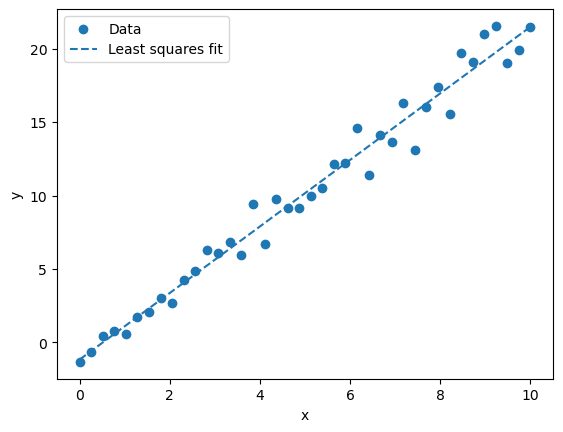

In [2]:
data = pd.read_csv("./weighted_regression_dataset.csv")

x = data["x"].values
y = data["y"].values
sigma = data["sigma"].values

# Ordinary least squares fit (degree 1 polynomial)
a, b = np.polyfit(x, y, 1)
print("Slope a =", a)
print("Intercept b =", b)

# Create fitted line
x_fit = np.linspace(min(x), max(x), 100)
y_fit = a * x_fit + b

# Plot
plt.scatter(x, y, label="Data")
plt.plot(x_fit, y_fit, label="Least squares fit", linestyle='--')
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


## (b) Inverse Variance Weighted Least Squares Fit

### 1. Setup
Suppose we have $N$ data points $(x_i, y_i)$ each with a different measurement
uncertainty $\sigma_i$. We model:

$$y_i = a + b x_i + \epsilon_i, \quad \epsilon_i \sim \mathcal{N}(0, \sigma_i^2)$$

The inverse variance weight for each point is:

$$w_i = \frac{1}{\sigma_i^2}$$

Instead of minimizing ordinary least squares, we minimize the chi-square:

$$
\chi^2(a,b)
=
\sum_{i=1}^{N}
\frac{(y_i - a x_i - b)^2}{\sigma_i^2}
$$

### 2. Matrix formulation

Define the **design matrix**

$$
X =
\begin{pmatrix}
x_1 & 1 \\
x_2 & 1 \\
\vdots & \vdots \\
x_N & 1
\end{pmatrix}
$$

Define the parameter vector

$$
\beta =
\begin{pmatrix}
a \\
b
\end{pmatrix}
$$

Define the data vector

$$
y =
\begin{pmatrix}
y_1 \\
y_2 \\
\vdots \\
y_N
\end{pmatrix}
$$

Define the **weight matrix**

$$
W =
\begin{pmatrix}
\frac{1}{\sigma_1^2} & 0 & \cdots \\
0 & \frac{1}{\sigma_2^2} & \cdots \\
\vdots & & \ddots
\end{pmatrix}
= \Sigma^{-1}
$$

### 3. Minimizing chi-square

The chi-square can be written compactly as:

$$
\chi^2 = (y - X\beta)^T W (y - X\beta)
$$

Setting derivatives with respect to $\beta$ equal to zero gives:

$$
X^T W X \, \beta = X^T W y
$$

These are called the **weighted normal equations**.

Solving:

$$
\beta = (X^T W X)^{-1} X^T W y
$$

This gives analytic solution for slope $b$ and intercept $a$. 

Define:

$$S = \sum w_i, \quad
S_x = \sum w_i x_i, \quad
S_y = \sum w_i y_i, \quad
S_{xx} = \sum w_i x_i^2, \quad
S_{xy} = \sum w_i x_i y_i$$

Then

$$
a = \frac{S_y - \hat{b} S_x}{S}, \qquad
b = \frac{S S_{xy} - S_x S_y}{S S_{xx} - S_x^2}
$$

### 4. Parameter uncertainty

The parameter covariance matrix is:

$$
\text{Cov}(\beta) = (X^T W X)^{-1}
$$

So:

$$
\sigma_a^2 = \text{Cov}_{11} = \frac{S_{xx}}{S S_{xx} - S_x^2}, \qquad
\sigma_b^2 = \text{Cov}_{22} = \frac{S}{S S_{xx} - S_x^2}
$$

This comes directly from Gaussian likelihood theory.

### 5. Goodness of fit

After fitting, we compute:

$$
\chi^2 = \sum \frac{(y_i - y_i^{\text{fit}})^2}{\sigma_i^2}
$$

Degrees of freedom:

$$
\text{dof} = N - 2
$$

Reduced chi-square:

$$
\chi^2_{\text{red}} = \frac{\chi^2}{\text{dof}}
$$

If the model and uncertainties are correct, we expect:

$$
\chi^2_{\text{red}} \approx 1
$$

---

### Summary

The weighted least squares solution is:

$$
\boxed{
\beta = (X^T W X)^{-1} X^T W y
}
$$

- $X$ encodes the model  
- $W$ encodes measurement precision  
- $(X^T W X)^{-1}$ gives parameter uncertainties  

This framework generalizes to:

- Polynomial fitting  
- Multiple regression  
- Correlated uncertainties (replace $W$ with full covariance matrix $C^{-1}$)

Slope a = 2.2729946375137695
Intercept b = -1.1937607097944072
Uncertainty in a = 0.041151558011372304
Uncertainty in b = 0.11293731878029152
Reduced chi^2 = 1.1618833736947451


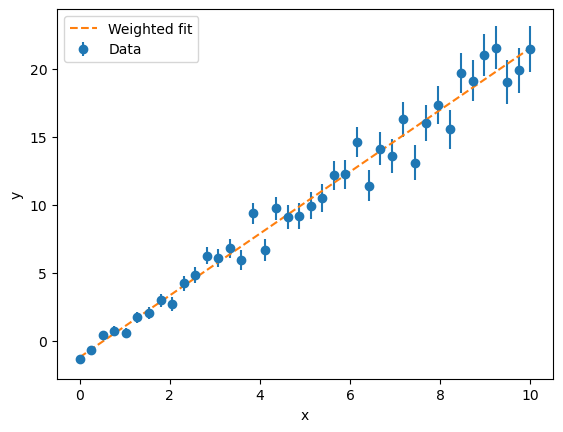

In [3]:
N = len(x)

# Construct design matrix X
# Column 1 = x
# Column 2 = 1 (for intercept)
X = np.column_stack((x, np.ones(N)))

# Construct weight matrix W (diagonal)
W = np.diag(1.0 / sigma**2)

# Convert y to column vector
y_vec = y.reshape(-1, 1)

# Compute beta = (X^T W X)^(-1) X^T W y
XTWX_inv = np.linalg.inv(X.T @ W @ X)
beta = XTWX_inv @ X.T @ W @ y_vec

# Extract parameters
a = beta[0, 0]
b = beta[1, 0]

print("Slope a =", a)
print("Intercept b =", b)

# Parameter covariance matrix
cov_matrix = XTWX_inv
sigma_a = np.sqrt(cov_matrix[0, 0])
sigma_b = np.sqrt(cov_matrix[1, 1])

print("Uncertainty in a =", sigma_a)
print("Uncertainty in b =", sigma_b)

# Compute chi^2
y_pred = (X @ beta).flatten()
chi2 = np.sum(((y - y_pred)/sigma)**2)
dof = N - 2
print("Reduced chi^2 =", chi2 / dof)

# Plot
x_fit = np.linspace(min(x), max(x), 100)
y_fit = a * x_fit + b

plt.errorbar(x, y, yerr=sigma, fmt='o', label="Data")
plt.plot(x_fit, y_fit, '--', label="Weighted fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


### Which Points Influence the Fit More Strongly?

Points with **small** $\sigma_i$ (small uncertainty) dominate the fit. A point with small (large) $\sigma_i$ is a precise (noisy) measurement — you trust it more (less). The concept is formalised by the weight $w_i = 1/\sigma_i^2$ : small (big) $\sigma_i$ gives large (small) weight .

---

### Why Does Inverse Variance Weighting Improve Parameter Estimation?

#### 1. It is the Maximum Likelihood solution

The log-likelihood for Gaussian errors is:

$$\log L(a, b) = -\frac{1}{2} \sum_{i=1}^{N} \frac{(y_i - a - bx_i)^2}{\sigma_i^2}$$

So Maximising this is equivalent to minimising the weighted chi-squared:

$$\chi^2 = \sum_{i=1}^{N} w_i (y_i - a - bx_i)^2, \quad w_i = \frac{1}{\sigma_i^2}$$

So inverse variance weighting is the statistically optimal solution given Gaussian noise.

#### 2. It is the Minimum Variance Estimator

By the **Gauss-Markov theorem**, the inverse variance weighted estimator
is the Best Linear Unbiased Estimator (BLUE) — no other linear unbiased
estimator has smaller variance on the fitted parameters $a$ and $b$.


**Activity 3**

### Starter code and helper functions for problem 3

Caleb Fink - Phys 657, Spring 2026

In [4]:
# imports 
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import rfft, fft, ifft, fftfreq, rfftfreq
from scipy.optimize import curve_fit
from scipy.stats import norm

#### Notes about data

* Data are in units of Voltage per time in seconds
* length of events are all 4096 bins long
* the sample rate is 5kHz, which can be used to convert the bins into units of time
* For all pulse data, the pulse will be centered in the middle of the trace

### Load data and inspect a few traces to get a feel for what the data look like

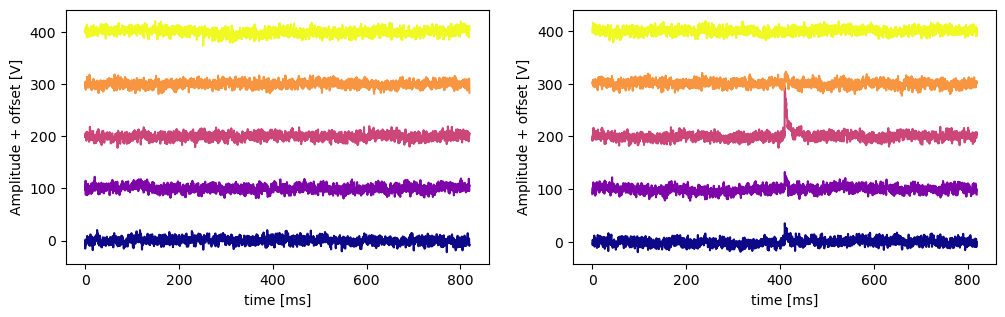

In [5]:
fs = 5e3
trace_length = 4096
dt = 1/fs

noise_data = np.load('noise_traces.npy') #should be (300,4096)
pulse_data = np.load('event_traces.npy') #should be (3000,4096)

# ── Combine all events ────────────────────────────────────────────────────────
all_data = np.vstack([noise_data, pulse_data])   # (3300, 4096)

#make array of event times
time = np.arange(trace_length)*dt #integer spaced data of lenth of traces, multiplied by time between samples


# use calc_psd() to calculate the PSD of the noise. Note, use the 
# flag 'folded_over=False' if you want the full two sided PSD which 
# is what the optimal filter expects. and use 'folded_over=True' if 
# want the one sided PSD for plotting. Also, the two sided PSD can be 
# folded over with the helper function 'foldpsd'

colors = plt.get_cmap("plasma")
c = colors(np.linspace(0,1,5))


fig, ax = plt.subplots(1,2,figsize=(12,3.3))
for ii in range(5):
    ax[0].plot(time*1e3, noise_data[ii]+ii*100, c=c[ii])# artificially adding a y-offset to seperate the data 
    ax[0].set_xlabel('time [ms]')
    ax[0].set_ylabel('Amplitude + offset [V]')
    ax[1].plot(time*1e3, pulse_data[ii]+ii*100, c=c[ii])# artificially adding a y-offset to seperate the data 
    ax[1].set_xlabel('time [ms]')
    ax[1].set_ylabel('Amplitude + offset [V]')


Helper functions for doing some of the calculations 

In [6]:
def foldpsd(psd, fs):
    """
    Return the one-sided version of the inputted two-sided psd. Supports an n-dimensional array outputted by `calc_psd`.
    
    Parameters
    ----------
    psd : ndarray
        A two-sided psd to be converted to one-sided
    fs : float
        The sample rate used for the psd

    Returns
    -------
    f : ndarray
        The frequencies corresponding to the outputted one-sided psd
    psd_folded : ndarray
        The one-sided (folded over) psd corresponding to the inputted two-sided psd

    """

    psd_len = psd.shape[-1]
    psd_folded = np.copy(psd[...,:psd_len//2 + 1])
    psd_folded[..., 1:psd_len//2 + (psd_len)%2] *= 2.0
    f = rfftfreq(psd_len, d=1.0/fs)
    
    return f, psd_folded


def calc_psd(x, fs=1.0, folded_over=True):
    """Return the PSD of an n-dimensional array, assuming that we want the PSD of the last axis.
    
    Parameters
    ----------
    x : array_like
        Array to calculate PSD of.
    fs : float, optional
        Sample rate of the data being taken, assumed to be in units of Hz.
    folded_over : bool, optional
        Boolean value specifying whether or not the PSD should be folded over. 
        If True, then the symmetric values of the PSD are multiplied by two, and
        we keep only the positive frequencies. If False, then the entire PSD is 
        saved, including positive and negative frequencies. Default is to fold
        over the PSD.
            
    Returns
    -------
    f : ndarray
        Array of sample frequencies
    psd : ndarray
        Power spectral density of 'x'
        
    """
    
    # calculate normalization for correct units
    norm = fs * x.shape[-1]
    
    if folded_over:
        # if folded_over = True, we calculate the Fourier Transform for only the positive frequencies
        if len(x.shape)==1:
            psd = (np.abs(rfft(x))**2.0)/norm
        else:
            psd = np.mean(np.abs(rfft(x))**2.0, axis=0)/norm
            
        # multiply the necessary frequencies by two (zeroth frequency should be the same, as
        # should the last frequency when x.shape[-1] is odd)
        psd[1:x.shape[-1]//2+1 - (x.shape[-1]+1)%2] *= 2.0
        f = rfftfreq(x.shape[-1], d=1.0/fs)
    else:
        # if folded_over = False, we calculate the Fourier Transform for all frequencies
        if len(x.shape)==1:
            psd = (np.abs(fft(x))**2.0)/norm
        else:
            psd = np.mean(np.abs(fft(x))**2.0, axis=0)/norm
            
        f = fftfreq(x.shape[-1], d=1.0/fs)
    return f, psd

def optimal_filter_amp(signal, template, psd, fs, coupling="AC"):
    """
    Compute the no-delay optimal filter amplitude for a single trace.

    Conventions / assumptions
    -------------------------
    - 'psd' is the full two-sided PSD (length = nbins).
    - FFT normalization follows the convention used in the OptimalFilter class:
        S = fft(template) / nbins / df
        V = fft(signal)   / nbins / df
      where df = fs / nbins.
    - If coupling == "AC" then the zero-frequency bin is ignored (psd[0] set to inf).
    - No time-shifts, no integralnorm, no chi2 / interpolation — just amplitude + sigma.

    Parameters
    ----------
    signal : 1D ndarray
        Time-domain trace (length nbins).
    template : 1D ndarray
        Template pulse (length nbins). Should be aligned/sampled to same grid.
    psd : 1D ndarray
        Two-sided PSD (length nbins). Can contain np.inf at index 0 for AC coupling.
    fs : float
        Sampling rate in Hz.
    coupling : {"AC","DC"}, optional
        If "AC" (default) will set psd[0] = np.inf to ignore DC.

    Returns
    -------
    amp : float
        Optimal filter amplitude (real scalar).
    sigma : float
        Expected 1-sigma amplitude resolution: 1/sqrt(norm).
    """
    signal = np.asarray(signal)
    template = np.asarray(template)
    psd = np.asarray(psd)

    if signal.ndim != 1 or template.ndim != 1 or psd.ndim != 1:
        raise ValueError("signal, template, and psd must be 1D arrays")

    nbins = signal.size
    if not (template.size == nbins == psd.size):
        raise ValueError("signal, template, and psd must have the same length")

    # frequency spacing
    df = fs / nbins

    # make a safe copy of PSD and apply coupling choice
    psd_safe = psd.astype(float).copy()
    if coupling == "AC":
        psd_safe[0] = np.inf

    # avoid division by zero on other bins (tiny floor)
    tiny = np.finfo(float).tiny
    psd_safe = np.where(np.isfinite(psd_safe), np.maximum(psd_safe, tiny), psd_safe)

    # FFT normalization matching the class conventions
    S = fft(template) / nbins / df   # complex
    V = fft(signal)   / nbins / df   # complex

    # frequency-domain filter (phi) and normalization (norm)
    phi = np.conjugate(S) / psd_safe
    norm = np.real(np.dot(phi, S)) * df   # scalar, should be >0 for nonzero template

    if norm <= 0:
        raise RuntimeError("Computed norm is non-positive (check template/psd)")

    # matched numerator
    num = np.sum(phi * V) * df         # complex in general
    amp = np.real(num) / norm          # final amplitude (real)

    # expected 1-sigma energy resolution
    sigma = 1.0 / np.sqrt(norm)

    return amp, sigma
    

### I Matched Filter Amplitude

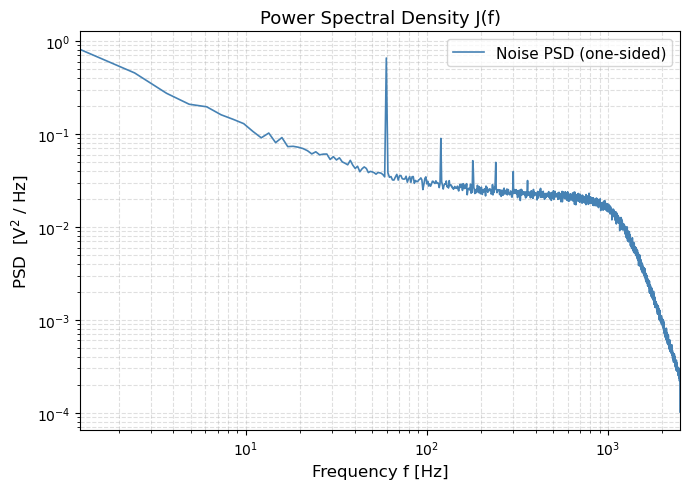

In [7]:
# ── compute PSDs ─────────────────────────────────────────────────────────────
# Two-sided PSD (needed later for the optimal filter)
f_two, psd_two = calc_psd(noise_data, fs=fs, folded_over=False)

# One-sided PSD for plotting (fold the two-sided result)
f_one, psd_one = foldpsd(psd_two, fs)

# ── plot one-sided PSD ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

ax.loglog(f_one[1:], psd_one[1:], color='steelblue', lw=1.2,
          label='Noise PSD (one-sided)')

ax.set_xlabel('Frequency f [Hz]',  fontsize=12)
ax.set_ylabel(r'PSD  [V$^2$ / Hz]', fontsize=12)
ax.set_title('Power Spectral Density J(f)', fontsize=13)

ax.set_xlim(f_one[1], fs / 2)          # DC bin excluded; Nyquist as upper limit
ax.grid(True, which='both', ls='--', alpha=0.4)
ax.legend(fontsize=11)

plt.tight_layout()
# plt.savefig('noise_psd.png', dpi=150)
plt.show()


Pulse peak index    : 2051
Template peak index : 2053
Matched-filter amplitude resolution (σ): 2.4985 V
Amplitude range : -7.012  →  52.892 V
Median amplitude: 20.5704 V


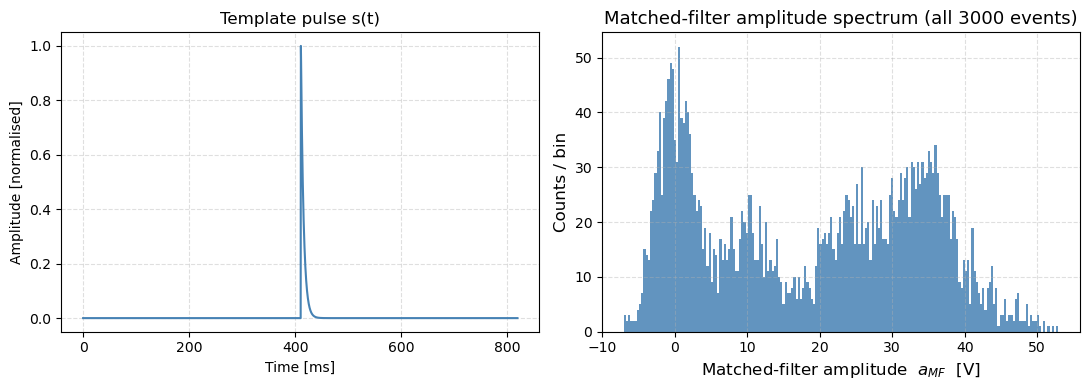

In [8]:
# ── parameters ───────────────────────────────────────────────────────────────
tau_rise = 100e-6   # 100 µs
tau_fall = 5e-3     #   5 ms

# ── 1. noise PSD (two-sided, needed by optimal_filter_amp) ───────────────────
f_two, psd_two = calc_psd(noise_data, fs=fs, folded_over=False)

# ── 2. build template s(t) ALIGNED to pulse peak  ◀ THE FIX ────────────────────
pulse_peak_idx = int(np.median(np.argmax(pulse_data, axis=1)))
t_shifted      = time - time[pulse_peak_idx]
# clip to avoid overflow in exp — values before peak get zeroed anyway
t_clipped      = np.clip(t_shifted, 0, None)   # only keep t >= 0
# Causal bi-exponential starting at t=t_shifted; peak is near tau_rise
template_raw   = np.exp(-t_clipped / tau_fall) - np.exp(-t_clipped / tau_rise)
template_raw   = np.where(t_shifted < 0, 0.0, template_raw)

# Normalise so max amplitude = 1
template = template_raw / template_raw.max()

print(f"Pulse peak index    : {pulse_peak_idx}")
print(f"Template peak index : {np.argmax(template)}")

# ── 3. quick sanity-check plot ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
ax.plot(time * 1e3, template, color='steelblue', lw=1.5)
ax.set_xlabel('Time [ms]')
ax.set_ylabel('Amplitude [normalised]')
ax.set_title('Template pulse s(t)')
ax.grid(True, ls='--', alpha=0.4)
plt.tight_layout()

# ── 4. apply matched filter to every event trace ─────────────────────────────
n_events =  all_data.shape[0]
mf_amps  = np.zeros(n_events)
mf_sigmas = np.zeros(n_events)

for i, trace in enumerate(all_data):
    amp, sigma = optimal_filter_amp(
        signal   = trace,
        template = template,
        psd      = psd_two,
        fs       = fs,
        coupling = "AC"          # ignores DC bin
    )
    mf_amps[i]   = amp
    mf_sigmas[i] = sigma

# sigma is the same for every trace (depends only on template + PSD)
print(f"Matched-filter amplitude resolution (σ): {mf_sigmas[0]:.4f} V")
print(f"Amplitude range : {mf_amps.min():.3f}  →  {mf_amps.max():.3f} V")
print(f"Median amplitude: {np.median(mf_amps):.4f} V")

# ── 5. plot amplitude distribution ───────────────────────────────────────────
ax = axes[1]
ax.hist(mf_amps, bins=200, color='steelblue', edgecolor='none', alpha=0.85)
ax.set_xlabel('Matched-filter amplitude  $a_{MF}$  [V]', fontsize=12)
ax.set_ylabel('Counts / bin', fontsize=12)
ax.set_title('Matched-filter amplitude spectrum (all 3000 events)', fontsize=13)
ax.grid(True, ls='--', alpha=0.4)
plt.tight_layout()
plt.show()


### II Spectral Model and Peak Extraction

In [11]:
def _pick_top_hist_peaks(counts, centers, n):
    """Pick up to n well-separated peak centers from histogram counts."""
    sm = np.convolve(counts, np.ones(3)/3, mode='same')
    order = np.argsort(sm)[::-1]
    chosen = []
    min_sep = (centers[1] - centers[0]) * 6.0
    for idx in order:
        c = centers[idx]
        if all(abs(c - cc) > min_sep for cc in chosen):
            chosen.append(c)
        if len(chosen) >= n:
            break
    if len(chosen) < n:
        # fallback: even spacing
        qs = np.linspace(0.1, 0.9, n)
        chosen = list(np.quantile(centers, qs))
    return np.array(sorted(chosen))


def fit_spectrum_curvefit(amplitudes,
                          n_lines=3,
                          mus_guess=None,
                          sig_guess=None,
                          include_flat=True,
                          bins=120,
                          range_vals=None,
                          verbose=False):
    """
    Fit binned counts with n_lines Gaussians + optional flat background using scipy.curve_fit.

    Parameters
    ----------
    amplitudes : 1D array
        Amplitude measurements (one number per event).
    n_lines : int
        Number of Gaussian spectral lines to fit.
    mus_guess : sequence or None
        Optional initial guesses for Gaussian centers (length n_lines). If None, inferred from histogram peaks.
    sig_guess : sequence or None
        Optional initial guesses for standard deviations (length n_lines). If None, default small values based on data span.
    include_flat : bool
        If True, include a flat counts-per-bin background term.
    bins, range_vals : histogram binning passed to np.histogram
    verbose : bool
        Print fitted parameter summary.

    Returns
    -------
    result : dict with keys
        'bin_centers','bin_edges','counts','areas','mus','sigs','weights',
        'flat_counts_per_bin','flat_fraction_est','model_counts','popt','pcov'
    """
    x = np.asarray(amplitudes).ravel()
    N = x.size

    counts, edges = np.histogram(x, bins=bins, range=range_vals)
    centers = 0.5 * (edges[:-1] + edges[1:])
    bw = edges[1] - edges[0]
    span = edges[-1] - edges[0]

    n_gauss = int(n_lines)
    # default guesses
    if mus_guess is None:
        mus_guess = _pick_top_hist_peaks(counts, centers, n_gauss)
    else:
        mus_guess = np.asarray(mus_guess).ravel()
        if mus_guess.size != n_gauss:
            raise ValueError("mus_guess must have length == n_lines")

    if sig_guess is None:
        # narrow for lines: few percent of span
        sig_guess = np.full(n_gauss, max(1e-3, 0.03 * span))
    else:
        sig_guess = np.asarray(sig_guess).ravel()
        if sig_guess.size != n_gauss:
            raise ValueError("sig_guess must have length == n_lines")

    # Model: counts per bin = sum_j area_j * pdf(center | mu_j, sigma_j) * bin_width + flatC
    def _model_counts(x_centers, *p):
        out = np.zeros_like(x_centers, dtype=float)
        ptr = 0
        for g in range(n_gauss):
            area = p[ptr]; mu = p[ptr+1]; sig = p[ptr+2]
            ptr += 3
            out += area * norm.pdf(x_centers, loc=mu, scale=max(1e-9, abs(sig))) * bw
        if include_flat:
            flatC = p[ptr]
            out = out + max(0.0, flatC)
        return out

    # initial parameter vector p0: [area1, mu1, sig1, area2, mu2, sig2, ..., flatC?]
    total_guess_area = N
    base_area = total_guess_area / (n_gauss + (1 if include_flat else 0))
    p0 = []
    for i in range(n_gauss):
        # approximate peak height -> area guess (robust)
        idx_closest = np.argmin(np.abs(centers - mus_guess[i]))
        peak_h = counts[idx_closest]
        est_area = peak_h * (sig_guess[i] * np.sqrt(2*np.pi))
        est_area = max(est_area, base_area * 0.1)
        p0.extend([float(est_area), float(mus_guess[i]), float(sig_guess[i])])

    if include_flat:
        flat_guess = max(0.0, np.median(counts) * 0.2)
        p0.append(float(flat_guess))

    p0 = np.asarray(p0, dtype=float)

    # bounds
    lower = []
    upper = []
    for g in range(n_gauss):
        lower.extend([0.0, edges[0] - 0.2*span, 1e-6])        # area >=0, mu within extended range, sig > 0
        upper.extend([N*10.0, edges[-1] + 0.2*span, span*1.0])
    if include_flat:
        lower.append(0.0)
        upper.append(float(N*0.5))

    try:
        popt, pcov = curve_fit(_model_counts, centers, counts, p0=p0, bounds=(lower, upper), maxfev=50000)
    except Exception as exc:
        if verbose:
            print("curve_fit exception (retrying without bounds):", exc)
        popt, pcov = curve_fit(_model_counts, centers, counts, p0=p0, maxfev=50000)

    # unpack
    ptr = 0
    areas = []
    mus = []
    sigs = []
    for g in range(n_gauss):
        a = float(popt[ptr]); mu = float(popt[ptr+1]); s = abs(float(popt[ptr+2]))
        ptr += 3
        areas.append(a); mus.append(mu); sigs.append(s)

    flatC = float(popt[ptr]) if include_flat else 0.0

    # approximate fractions (area-weighted)
    denom = np.sum(areas) + (flatC * span / bw if include_flat else 0.0)
    if denom <= 0:
        weights = np.array([a / max(1e-12, np.sum(areas)) for a in areas])
        flat_frac = 0.0
    else:
        weights = np.array(areas) / denom
        flat_frac = (flatC * span / bw) / denom if include_flat else 0.0

    model_counts = _model_counts(centers, *popt)

    result = {
        "bin_centers": centers,
        "bin_edges": edges,
        "counts": counts,
        "areas": np.array(areas),
        "mus": np.array(mus),
        "sigs": np.array(sigs),
        "weights": weights,
        "flat_counts_per_bin": float(flatC),
        "flat_fraction_est": float(flat_frac),
        "model_counts": model_counts,
        "popt": popt,
        "pcov": pcov
    }

    if verbose:
        print("mus:", result["mus"])
        print("sigs:", result["sigs"])
        print("areas:", result["areas"])
        print("flat per bin:", result["flat_counts_per_bin"])
        print("flat fraction (est):", result["flat_fraction_est"])

    return result


In [10]:
## plotting helper 
res = fit_spectrum_curvefit(data, n_lines=4, mus_guess=(0,20,60,80),sig_guess=(3,3,3,3), include_flat=True,
                            bins=120, range_vals=( -10, 110 ), verbose=True)

plt.figure(figsize=(8,4))
plt.bar(res['bin_centers'], res['counts'], width=res['bin_edges'][1]-res['bin_edges'][0], alpha=0.35, label='data (counts)')
plt.plot(res['bin_centers'], res['model_counts'], 'k-', lw=2, )

for i,a in enumerate(res['areas']):
    comp = a * norm.pdf(res['bin_centers'], loc=res['mus'][i], scale=res['sigs'][i]) * (res['bin_edges'][1]-res['bin_edges'][0])
    plt.plot(res['bin_centers'], comp, lw=1.5, label=f'gauss {i+1} (μ={res['mus'][i]:.0f}, σ={res['sigs'][i]:.0f})')
plt.xlabel('amplitude'); plt.ylabel('counts'); plt.legend()
plt.yscale('log')
plt.ylim(1e1, 1e4)
plt.tight_layout()


SyntaxError: f-string: unmatched '[' (1522833119.py, line 11)

mus: [-1.86823282e-03  1.00646924e+01  2.33720969e+01  3.42326575e+01]
sigs: [2.47678796 3.49755757 3.44986478 4.42819669]
areas: [ 891.1891647   496.22820364  515.63901152 1036.79832913]
flat per bin: 1.811096353231264
flat fraction (est): 0.10969447470909185

── Fit results ──────────────────────────────────────────────────
  Noise blob    μ = -0.0019 V   σ = 2.4768 V   area = 891.2
  Peak A1       μ = 10.0647 V   σ = 3.4976 V   area = 496.2
  Peak A2       μ = 23.3721 V   σ = 3.4499 V   area = 515.6
  Peak A3       μ = 34.2327 V   σ = 4.4282 V   area = 1036.8
  Flat bkg      1.81 counts/bin


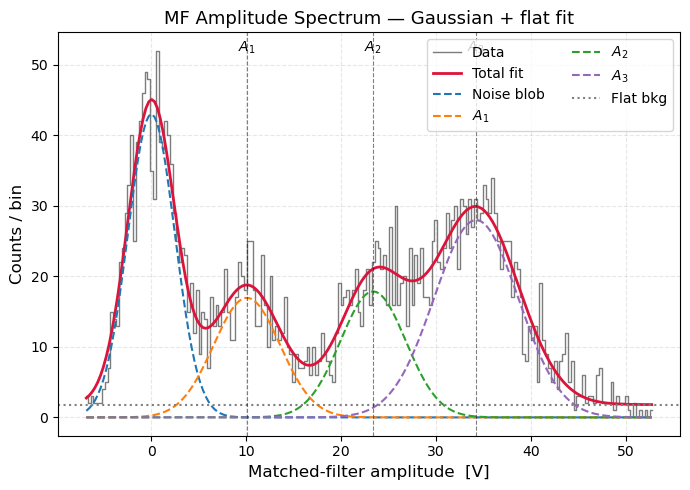


── NLL scan: μ₁ ─────────────────────────────────────────────────
  Best-fit μ₁  = 10.06469 V
  NLL scan σ   = 0.23395 V   (from ΔNLL=0.5 crossing)


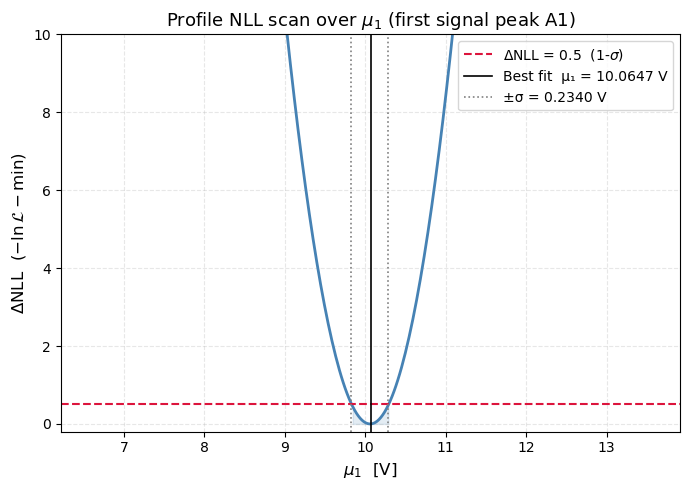

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm as scipy_norm
from scipy.special import gammaln

# ── 1. Fit the MF amplitude spectrum ─────────────────────────────────────────
result = fit_spectrum_curvefit(
    amplitudes  = mf_amps,
    n_lines     = 4,          # 3 signal peaks + 1 noise blob
    mus_guess=(0,10,20,30),
    include_flat= True,       # flat random-trigger background
    bins        = 200,
    verbose     = True
)

# Unpack fit results (sorted by mu)
sort_idx = np.argsort(result['mus'])
mus      = result['mus'][sort_idx]
sigs     = result['sigs'][sort_idx]
areas    = result['areas'][sort_idx]
flatC    = result['flat_counts_per_bin']

centers      = result['bin_centers']
counts       = result['counts']
model_counts = result['model_counts']
edges        = result['bin_edges']
bw           = edges[1] - edges[0]

# Label components: noise blob = narrowest/lowest-mu; signal peaks = the rest
# (adjust labelling below if your histogram shows a different ordering)
noise_blob_idx = 0                      # lowest-amplitude Gaussian = noise blob
signal_idx     = [1, 2, 3]             # the three nuclear-decay lines

print("\n── Fit results ──────────────────────────────────────────────────")
labels = ['Noise blob', 'Peak A1', 'Peak A2', 'Peak A3']
for i, lab in enumerate(labels):
    print(f"  {lab:12s}  μ = {mus[i]:.4f} V   σ = {sigs[i]:.4f} V   area = {areas[i]:.1f}")
print(f"  Flat bkg      {flatC:.2f} counts/bin")

A1, A2, A3 = mus[1], mus[2], mus[3]
s1, s2, s3 = sigs[1], sigs[2], sigs[3]

# ── 2. Spectrum plot with all components ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

# histogram
ax.step(centers, counts, where='mid', color='#444', lw=1.0,
        alpha=0.7, label='Data')

# total model
ax.plot(centers, model_counts, color='crimson', lw=2, label='Total fit')

# individual Gaussians
comp_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']
comp_labels = ['Noise blob', r'$A_1$', r'$A_2$', r'$A_3$']
for i in range(4):
    g = areas[i] * scipy_norm.pdf(centers, loc=mus[i], scale=sigs[i]) * bw
    ax.plot(centers, g, '--', lw=1.5, color=comp_colors[i], label=comp_labels[i])

# flat background
ax.axhline(flatC, color='gray', ls=':', lw=1.5, label='Flat bkg')

# annotate peak positions
for mu, lab in zip([A1, A2, A3], [r'$A_1$', r'$A_2$', r'$A_3$']):
    ax.axvline(mu, color='k', ls='--', lw=0.8, alpha=0.5)
    ax.text(mu, ax.get_ylim()[1]*0.95, lab, ha='center', fontsize=10)

ax.set_xlabel('Matched-filter amplitude  [V]', fontsize=12)
ax.set_ylabel('Counts / bin', fontsize=12)
ax.set_title('MF Amplitude Spectrum — Gaussian + flat fit', fontsize=13)
ax.legend(fontsize=10, ncol=2)
ax.grid(True, ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

# ── 3. Negative log-likelihood scan over μ₁ ───────────────────────────────────
# Poisson NLL: -ln L = sum_i [ lambda_i - k_i * ln(lambda_i) ]  (dropping ln k_i! )

def model_lambda(mu1_scan, centers, bw,
                 mus_fixed, sigs_fixed, areas_fixed, flatC,
                 signal_peak_idx=1):
    """Rebuild expected counts per bin, varying only mu_1."""
    lam = np.zeros_like(centers)
    for i in range(4):
        mu_i = mu1_scan if i == signal_peak_idx else mus_fixed[i]
        lam += areas_fixed[i] * scipy_norm.pdf(centers, loc=mu_i,
                                                scale=sigs_fixed[i]) * bw
    lam += flatC
    return np.maximum(lam, 1e-30)   # avoid log(0)

def poisson_nll(lam, k):
    """Poisson negative log-likelihood (dropping constant ln k! term)."""
    return np.sum(lam - k * np.log(lam))

# scan window: ±σ₁ around fitted A1
n_scan   = 300
mu1_grid = np.linspace(A1 - s1, A1 + s1, n_scan)
nll_vals = np.array([
    poisson_nll(
        model_lambda(m, centers, bw, mus, sigs, areas, flatC, signal_peak_idx=1),
        counts
    )
    for m in mu1_grid
])

nll_min   = nll_vals.min()
delta_nll = nll_vals - nll_min          # shift so minimum = 0

# 1-sigma uncertainty from ΔNLL = 0.5 crossing
cross = np.where(np.diff((delta_nll < 0.5).astype(int)))[0]
mu1_lo = mu1_grid[cross[0]]  if len(cross) >= 1 else np.nan
mu1_hi = mu1_grid[cross[-1]] if len(cross) >= 2 else np.nan
sigma_nll = (mu1_hi - mu1_lo) / 2

print(f"\n── NLL scan: μ₁ ─────────────────────────────────────────────────")
print(f"  Best-fit μ₁  = {A1:.5f} V")
print(f"  NLL scan σ   = {sigma_nll:.5f} V   (from ΔNLL=0.5 crossing)")

# ── 4. Diagnostic NLL plot ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(mu1_grid, delta_nll, color='steelblue', lw=2)
ax.axhline(0.5, color='crimson', ls='--', lw=1.5, label=r'$\Delta$NLL = 0.5  (1-$\sigma$)')
ax.axvline(A1,    color='k',       ls='-',  lw=1.2, label=f'Best fit  μ₁ = {A1:.4f} V')
ax.axvline(mu1_lo, color='gray',  ls=':',  lw=1.2)
ax.axvline(mu1_hi, color='gray',  ls=':',  lw=1.2,
           label=f'±σ = {sigma_nll:.4f} V')

ax.fill_between(mu1_grid, 0, delta_nll,
                where=(delta_nll < 0.5), alpha=0.15, color='steelblue')

ax.set_xlabel(r'$\mu_1$  [V]', fontsize=12)
ax.set_ylabel(r'$\Delta$NLL  ($-\ln\mathcal{L} - \min$)', fontsize=12)
ax.set_title(r'Profile NLL scan over $\mu_1$ (first signal peak A1)', fontsize=13)
ax.set_ylim(-0.2, min(10, delta_nll.max()*1.1))
ax.legend(fontsize=10)
ax.grid(True, ls='--', alpha=0.3)
plt.tight_layout()
plt.show()


### III Energy Calibration

── Calibration input ────────────────────────────────────────────
  Line 1: E_true = 25.0 keV   A_meas = 10.0647 ± 3.4976 V
  Line 2: E_true = 65.0 keV   A_meas = 23.3721 ± 3.4499 V
  Line 3: E_true = 100.0 keV   A_meas = 34.2327 ± 4.4282 V

── Saturation model fit ─────────────────────────────────────────
  a = 106.4091 ± 215.3169  (saturation amplitude)
  b = 259.0193 ± 613.5248  (saturation energy scale [keV])
  χ²/dof = 0.012 / 1 = 0.012

── Inverse calibration check ────────────────────────────────────
  Line 1: E_true=25.0 keV  → A_meas=10.0647 V  → E_rec=25.74 keV  (residual +0.74 keV)
  Line 2: E_true=65.0 keV  → A_meas=23.3721 V  → E_rec=64.24 keV  (residual -0.76 keV)
  Line 3: E_true=100.0 keV  → A_meas=34.2327 V  → E_rec=100.55 keV  (residual +0.55 keV)

  Events converted: 2822 / 3300
  Energy range: 0.0 – 178.0 keV



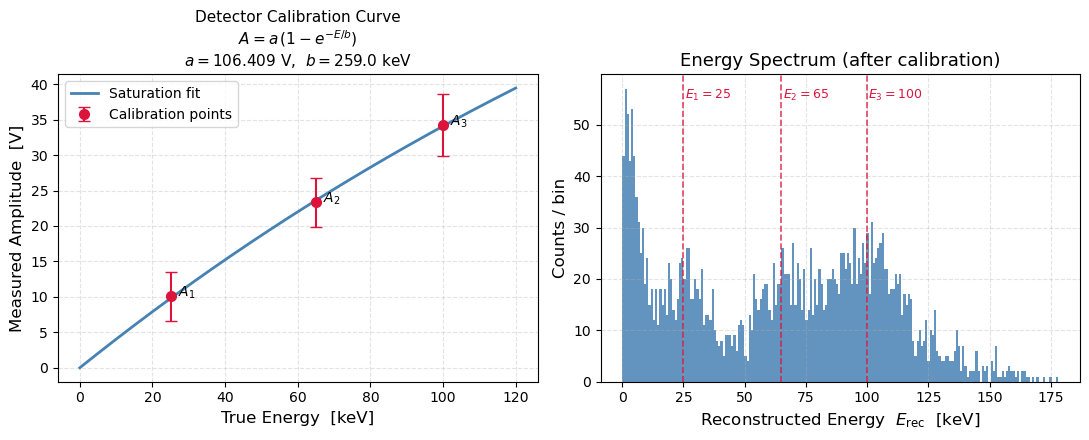

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ── True energies of the three lines ─────────────────────────────────────────
E_true = np.array([25.0, 65.0, 100.0])   # keV

# ── Measured amplitudes from the MF fit (A1, A2, A3) ─────────────────────────
# These come from your fit_spectrum_curvefit result (sorted by mu)
A_meas = np.array([A1, A2, A3])           # V  — from previous step
A_err  = np.array([s1, s2, s3])           # V  — Gaussian widths as uncertainties
# A_err = [s1/np.sqrt(areas[1]), s2/np.sqrt(areas[2]), s3/np.sqrt(areas[3])]
# i.e. sigma_nll from the NLL scan

print("── Calibration input ────────────────────────────────────────────")
for i in range(3):
    print(f"  Line {i+1}: E_true = {E_true[i]:.1f} keV   A_meas = {A_meas[i]:.4f} ± {A_err[i]:.4f} V")

# ── 1. Fit saturation model  E_recon = a*(1 - exp(-E_true/b)) ────────────────
#    Rearranged: A_meas = a*(1 - exp(-E_true/b))
#    i.e. the measured amplitude IS E_recon in detector units

def saturation_model(E, a, b):
    """Forward model: measured amplitude as function of true energy."""
    return a * (1.0 - np.exp(-E / b))

# Initial guesses: a ~ max amplitude, b ~ mid-range energy
p0 = [A_meas.max() * 1.2, 50.0]

popt, pcov = curve_fit(
    saturation_model,
    E_true, A_meas,
    p0     = p0,
    sigma  = A_err,
    absolute_sigma = True,
    maxfev = 10000
)
perr = np.sqrt(np.diag(pcov))

a_fit, b_fit = popt
a_err, b_err = perr

print(f"\n── Saturation model fit ─────────────────────────────────────────")
print(f"  a = {a_fit:.4f} ± {a_err:.4f}  (saturation amplitude)")
print(f"  b = {b_fit:.4f} ± {b_err:.4f}  (saturation energy scale [keV])")

# Goodness of fit
A_pred    = saturation_model(E_true, *popt)
residuals = A_meas - A_pred
chi2      = np.sum((residuals / A_err)**2)
print(f"  χ²/dof = {chi2:.3f} / {len(E_true)-2} = {chi2/(len(E_true)-2):.3f}")

# ── 2. Inverse calibration: A_meas → E_rec ───────────────────────────────────
# Invert  A = a*(1 - exp(-E/b))
#   E_rec = -b * ln(1 - A/a)

def inverse_calibration(A, a, b):
    """Convert measured amplitude [V] to reconstructed energy [keV]."""
    ratio = A / a
    # clip to valid domain (ratio must be in (0,1) for physical energies)
    ratio = np.clip(ratio, 1e-9, 1.0 - 1e-9)
    return -b * np.log(1.0 - ratio)

# verify on calibration points
E_rec_check = inverse_calibration(A_meas, a_fit, b_fit)
print(f"\n── Inverse calibration check ────────────────────────────────────")
for i in range(3):
    print(f"  Line {i+1}: E_true={E_true[i]:.1f} keV  "
          f"→ A_meas={A_meas[i]:.4f} V  "
          f"→ E_rec={E_rec_check[i]:.2f} keV  "
          f"(residual {E_rec_check[i]-E_true[i]:+.2f} keV)")

def sigma_energy(A, sigma_A, a, b):
    """
    Propagate amplitude resolution sigma_A [V] to energy resolution sigma_E [keV]
    using the derivative of the inverse calibration.
    """
    dEdA = b / (a - A)        # derivative of inverse calibration
    return dEdA * sigma_A     # sigma_E in keV
    
# ── 3. Convert full amplitude spectrum to energy spectrum ─────────────────────
# Filter to valid range (amplitudes must be < a_fit for log to be defined)
valid = (mf_amps > 0) & (mf_amps < a_fit * 0.999)
E_rec_all = inverse_calibration(mf_amps[valid], a_fit, b_fit)

print(f"\n  Events converted: {valid.sum()} / {len(mf_amps)}")
print(f"  Energy range: {E_rec_all.min():.1f} – {E_rec_all.max():.1f} keV\n")

# ── Calibration curve plot ────────────────────────────────────────────────────
E_fine = np.linspace(0, 120, 500)
A_fine = saturation_model(E_fine, *popt)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
ax.plot(E_fine, A_fine, color='steelblue', lw=2, label='Saturation fit')
ax.errorbar(E_true, A_meas, yerr=A_err, fmt='o', color='crimson',
            capsize=4, ms=7, label='Calibration points')
for i, (e, a) in enumerate(zip(E_true, A_meas)):
    ax.annotate(f'$A_{i+1}$', xy=(e, a), xytext=(e+2, a-0.01), fontsize=10)
ax.set_xlabel('True Energy  [keV]', fontsize=12)
ax.set_ylabel('Measured Amplitude  [V]', fontsize=12)
ax.set_title('Detector Calibration Curve\n'
             r'$A = a\,(1-e^{-E/b})$'
             f'\n$a={a_fit:.3f}$ V,  $b={b_fit:.1f}$ keV', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, ls='--', alpha=0.35)

# ── Energy spectrum plot ──────────────────────────────────────────────────────
ax = axes[1]
ax.hist(E_rec_all, bins=200, color='steelblue', edgecolor='none', alpha=0.85)
for e, lab in zip(E_true, [r'$E_1=25$', r'$E_2=65$', r'$E_3=100$']):
    ax.axvline(e, color='crimson', ls='--', lw=1.2, alpha=0.8)
    ax.text(e + 0.5, ax.get_ylim()[1] * 0.92, lab, fontsize=9, color='crimson')
ax.set_xlabel('Reconstructed Energy  $E_\\mathrm{rec}$  [keV]', fontsize=12)
ax.set_ylabel('Counts / bin', fontsize=12)
ax.set_title('Energy Spectrum (after calibration)', fontsize=13)
ax.grid(True, ls='--', alpha=0.35)

plt.tight_layout()
plt.show()


With only 3 calibration points the saturation model is the clearly better choice. A degree-2 polynomial would pass through all 3 points exactly, while the saturation model gives a physically meaningful fit with 1 degree of freedom to assess goodness of fit.

### IV Detection Threshold

── Detection threshold ──────────────────────────────────────────
  μ_n        = -0.0019 V
  σ_n        = 2.4768 V
  A_thresh   = μ_n + 5σ_n = 12.3821 V
  E_thresh   = 32.043 keV  (after calibration)


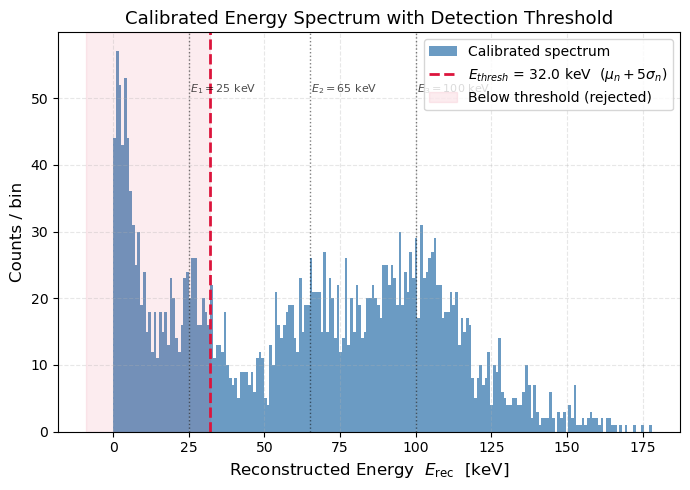


── Detection efficiency ─────────────────────────────────────────
  Events above threshold : 1936 / 2822
  Overall efficiency     : 68.6%
  A1 efficiency            : 286/1230 = 23.3%
  A2 efficiency            : 1207/1207 = 100.0%
  A3 efficiency            : 1601/1601 = 100.0%


In [27]:
# ── noise blob parameters (index 0 after sorting) ─────────────────────────────
mu_n  = mus[0]    # centre of noise blob [V]
sig_n = sigs[0]   # width of noise blob  [V]

# detection threshold in amplitude space
A_thresh = mu_n + 5 * sig_n
print(f"── Detection threshold ──────────────────────────────────────────")
print(f"  μ_n        = {mu_n:.4f} V")
print(f"  σ_n        = {sig_n:.4f} V")
print(f"  A_thresh   = μ_n + 5σ_n = {A_thresh:.4f} V")

# ── 1. Convert threshold to energy via inverse calibration ────────────────────
E_thresh = inverse_calibration(A_thresh, a_fit, b_fit)
print(f"  E_thresh   = {E_thresh:.3f} keV  (after calibration)")

# ── 2. Plot calibrated energy spectrum with threshold marked ──────────────────
fig, ax = plt.subplots(figsize=(7, 5))

# energy spectrum (only valid events)
ax.hist(E_rec_all, bins=200, color='steelblue', edgecolor='none',
        alpha=0.8, label='Calibrated spectrum')

# threshold line
ax.axvline(E_thresh, color='crimson', lw=2, ls='--',
           label=f'$E_{{thresh}}$ = {E_thresh:.1f} keV  ($\\mu_n + 5\\sigma_n$)')

# shade the region below threshold (below-threshold / rejected region)
ymax = ax.get_ylim()[1]
ax.axvspan(ax.get_xlim()[0], E_thresh, alpha=0.08, color='crimson',
           label='Below threshold (rejected)')

# mark true line energies for reference
for e, lab in zip(E_true, [r'$E_1=25$ keV', r'$E_2=65$ keV', r'$E_3=100$ keV']):
    ax.axvline(e, color='k', ls=':', lw=1.0, alpha=0.5)
    ax.text(e + 0.5, ymax * 0.85, lab, fontsize=8, color='k', alpha=0.7)

ax.set_xlabel('Reconstructed Energy  $E_\\mathrm{rec}$  [keV]', fontsize=12)
ax.set_ylabel('Counts / bin', fontsize=12)
ax.set_title('Calibrated Energy Spectrum with Detection Threshold', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

# ── efficiency above threshold ────────────────────────────────────────────────
n_above = np.sum(E_rec_all > E_thresh)
n_total = len(E_rec_all)
print(f"\n── Detection efficiency ─────────────────────────────────────────")
print(f"  Events above threshold : {n_above} / {n_total}")
print(f"  Overall efficiency     : {100*n_above/n_total:.1f}%")

# per-line efficiency (within ±3σ of each line)
for i, (e, s, lab) in enumerate(zip([A1,A2,A3],[s1,s2,s3],['A1','A2','A3'])):
    E_line_rec = inverse_calibration(
        mf_amps[(mf_amps > e - 3*s) & (mf_amps < e + 3*s)], a_fit, b_fit
    )
    n_line_above = np.sum(E_line_rec > E_thresh)
    n_line_total = len(E_line_rec)
    eff = 100 * n_line_above / n_line_total if n_line_total > 0 else 0
    print(f"  {lab} efficiency            : {n_line_above}/{n_line_total} = {eff:.1f}%")


### V Detection Efficiency

── Injection summary ────────────────────────────────────────────
  Energy range tested  : 0.0 – 150.0 keV
  Energies tested      : 30
  Injections per point : 100
  Total injections     : 3000
  E_thresh             : 32.04 keV

── Efficiency curve fit ─────────────────────────────────────────
  50% efficiency point : 32.04 ± 0.44 keV
  Turn-on width        : 6.58 ± 0.43 keV


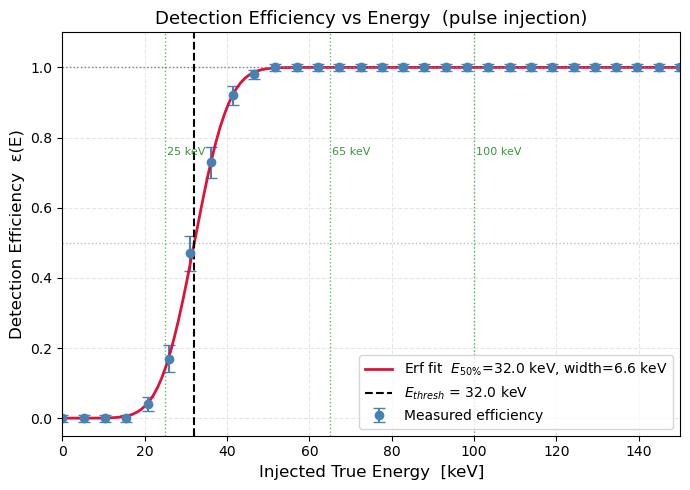

In [28]:
# ── Detection Efficiency via Pulse Injection ───────────────────────────────────

# energy grid to test — scan from well below to well above threshold
E_inject_grid = np.linspace(0, 150, 30)    # keV
n_inject_per_energy = 100                  # injected pulses per energy point
n_noise_traces = noise_data.shape[0]       # 300 noise traces available

efficiencies = np.zeros(len(E_inject_grid))

for ei, E_inj in enumerate(E_inject_grid):

    # convert true energy to expected amplitude using calibration
    A_inj = a_fit * (1.0 - np.exp(-E_inj / b_fit))   # [V]

    # inject into random noise traces
    n_detected = 0
    for j in range(n_inject_per_energy):
        # pick a random noise trace as the background
        noise_idx  = np.random.randint(0, n_noise_traces)
        noise_trace = noise_data[noise_idx]

        # inject: noise + scaled template
        injected_trace = noise_trace + A_inj * template

        # run matched filter
        amp, _ = optimal_filter_amp(
            signal   = injected_trace,
            template = template,
            psd      = psd_two,
            fs       = fs,
            coupling = "AC"
        )

        # convert MF amplitude to energy
        amp_clipped = np.clip(amp, 1e-9, a_fit * 0.999)
        E_rec_inj   = inverse_calibration(amp_clipped, a_fit, b_fit)

        # detection criterion
        if E_rec_inj > E_thresh:
            n_detected += 1

    efficiencies[ei] = n_detected / n_inject_per_energy

print("── Injection summary ────────────────────────────────────────────")
print(f"  Energy range tested  : {E_inject_grid.min():.1f} – {E_inject_grid.max():.1f} keV")
print(f"  Energies tested      : {len(E_inject_grid)}")
print(f"  Injections per point : {n_inject_per_energy}")
print(f"  Total injections     : {len(E_inject_grid)*n_inject_per_energy}")
print(f"  E_thresh             : {E_thresh:.2f} keV")

# ── Fit efficiency curve with error function (sigmoidal turn-on) ──────────────
from scipy.special import erf
from scipy.optimize import curve_fit as scipy_curve_fit

def efficiency_model(E, E50, width):
    """Sigmoidal efficiency curve — erf turn-on."""
    return 0.5 * (1.0 + erf((E - E50) / (np.sqrt(2) * width)))

# binomial uncertainty on efficiency
eff_err = np.sqrt(efficiencies * (1 - efficiencies) / n_inject_per_energy)
eff_err = np.where(eff_err == 0, 1/n_inject_per_energy, eff_err)  # avoid zero errors

try:
    popt_eff, pcov_eff = scipy_curve_fit(
        efficiency_model,
        E_inject_grid, efficiencies,
        p0     = [E_thresh, 5.0],
        sigma  = eff_err,
        absolute_sigma = True
    )
    E50_fit   = popt_eff[0]
    width_fit = popt_eff[1]
    perr_eff  = np.sqrt(np.diag(pcov_eff))
    print(f"\n── Efficiency curve fit ─────────────────────────────────────────")
    print(f"  50% efficiency point : {E50_fit:.2f} ± {perr_eff[0]:.2f} keV")
    print(f"  Turn-on width        : {width_fit:.2f} ± {perr_eff[1]:.2f} keV")
    fit_success = True
except Exception as e:
    print(f"  Efficiency fit failed: {e}")
    fit_success = False

# ── Plot efficiency vs energy ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

# data points with binomial error bars
ax.errorbar(E_inject_grid, efficiencies, yerr=eff_err,
            fmt='o', color='steelblue', capsize=4, ms=6,
            label='Measured efficiency')

# fitted curve
if fit_success:
    E_fine = np.linspace(0, 150, 150)
    ax.plot(E_fine, efficiency_model(E_fine, *popt_eff),
            color='crimson', lw=2,
            label=f'Erf fit  $E_{{50\\%}}$={E50_fit:.1f} keV, '
                  f'width={width_fit:.1f} keV')

# threshold and reference lines
ax.axvline(E_thresh, color='k', ls='--', lw=1.5,
           label=f'$E_{{thresh}}$ = {E_thresh:.1f} keV')
ax.axhline(1.0, color='gray', ls=':', lw=1)
ax.axhline(0.5, color='gray', ls=':', lw=1, alpha=0.5)

# mark true line energies
for e, lab in zip(E_true, ['25 keV', '65 keV', '100 keV']):
    ax.axvline(e, color='green', ls=':', lw=1.0, alpha=0.6)
    ax.text(e + 0.5, 0.75, lab, fontsize=8, color='green', alpha=0.8)

ax.set_xlabel('Injected True Energy  [keV]', fontsize=12)
ax.set_ylabel('Detection Efficiency  ε(E)', fontsize=12)
ax.set_title('Detection Efficiency vs Energy  (pulse injection)', fontsize=13)
ax.set_xlim(0, 150)
ax.set_ylim(-0.05, 1.1)
ax.legend(fontsize=10)
ax.grid(True, ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

sig_E_mf        = np.array([sigma_energy(A, sig, a_fit, b_fit) for A, sig in zip([A1, A2, A3], [s1, s2, s3])])
E_thresh_mf     = E_thresh 
efficiencies_mf = efficiencies.copy()
eff_err_mf      = eff_err.copy()
popt_eff_mf     = popt_eff.copy()
E50_mf          = E50_fit
width_mf        = width_fit


### VI Alternative Estimators

For each estimator you repeat the same downstream pipeline — only the amplitude extraction step changes.

**What changes — only the amplitude extraction:**

Instead of:
```python
amp, sigma = optimal_filter_amp(trace, template, psd_two, fs, coupling="AC")
```

For the **peak estimator**:
```python
amp = np.max(trace)
```

For the **integral estimator**:
```python
window_end = min(pulse_peak_idx + int(3 * tau_fall * fs), trace_length)
amp = np.sum(trace[pulse_peak_idx:window_end]) * dt
```

**What stays the same:**
- PSD calculation
- Template construction
- `fit_spectrum_curvefit`
- Calibration fit
- Threshold calculation
- Efficiency injection loop structure

**Then everything downstream is identical:**

amps = peak_amps  or integral_amps

↓

fit_spectrum_curvefit(amps, ...)

↓

calibration fit (new a, b)

↓

threshold (new E_thresh)

↓

efficiency injection (swap estimator inside loop)

The efficiency injection loop changes to:

```python
# peak estimator inside injection loop
injected_trace = noise_trace + A_inj * template
amp = np.max(injected_trace)

# integral estimator inside injection loop
amp = np.sum(injected_trace[window_start:window_end]) * dt
```

The key insight is that `mf_amps`, `peak_amps`, and `integral_amps` are all just arrays 
of shape `(3300,)` — one number per event. Everything downstream is identical, 
only diff is how that one number is computed from the raw event.

#### Energy Resolution via Error Propagation

The inverse calibration is:

$$E_{rec} (A) = -b \ln\left(1 - \frac{A}{a}\right)$$

$$\frac{dE}{dA} = \frac{b}{a - A}$$

By standard error propagation:

$$\sigma_E = \left|\frac{dE}{dA}\right| \cdot \sigma_A = \frac{b}{a - A} \cdot \sigma_A$$

#### Peak estimator: maximum sample value

── Amplitude estimator ──────────────────────────────────────────
Peak amps (noise)  mean : 20.909 V
Peak amps (pulses) mean : 48.866 V
Peak amps range         : 16.174 → 113.363 V
(3300,)

── Fit results ──────────────────────────────────────────────────
  Noise blob    μ = 20.1423 V   σ = 1.3666 V   area = 653.8
  Peak A1       μ = 23.1671 V   σ = 3.0893 V   area = 636.3
  Peak A2       μ = 59.5365 V   σ = 20.0210 V   area = 1745.1
  Peak A3       μ = 72.9448 V   σ = 6.3683 V   area = 312.6
  Flat bkg      0.00 counts/bin

── Saturation model fit ─────────────────────────────────────────
  a = 145.9174 ± 79.1823  (saturation amplitude)
  b = 143.5628 ± 101.5698  (saturation energy scale [keV])
  χ²/dof = 0.106 / 1 = 0.106

── Inverse calibration check ────────────────────────────────────
  A1: E_true=25.0 keV    A=23.167 V  →  E_rec=24.82 keV    σ_A=3.0893 V  →  σ_E=3.6131 keV  (resolution = 14.56%)
  A2: E_true=65.0 keV    A=59.537 V  →  E_rec=75.27 keV    σ_A=20.0210 V  →  σ_E=33.2

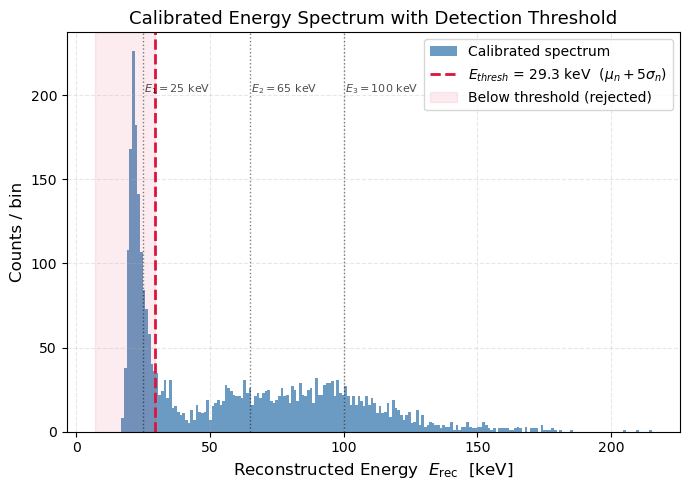


── Efficiency curve fit ─────────────────────────────────────────
  50% efficiency point : 23.20 ± 0.40 keV
  Turn-on width        : 5.44 ± 0.38 keV
[ 3.61305364 33.27441175 12.52878278]


In [80]:
# mf_amps, _ = optimal_filter_amp(all_data, template, psd_two, fs, coupling="AC")

# ─────────────────────────────────────────────────────────────────────────────
# Amplitude estimator
# ─────────────────────────────────────────────────────────────────────────────
# ── Peak estimator: maximum sample value ─────────────────────────────────────
peak_amps = np.max(all_data, axis=1)   # shape (3300,)

print("── Amplitude estimator ──────────────────────────────────────────")
print(f"Peak amps (noise)  mean : {peak_amps[:300].mean():.3f} V")
print(f"Peak amps (pulses) mean : {peak_amps[300:].mean():.3f} V")
print(f"Peak amps range         : {peak_amps.min():.3f} → {peak_amps.max():.3f} V")
print(peak_amps.shape)

# ─────────────────────────────────────────────────────────────────────────────
# Fit the amplitude spectrum
# ─────────────────────────────────────────────────────────────────────────────
# ── 1. Fit the amplitude spectrum ─────────────────────────────────────────
result = fit_spectrum_curvefit(
    amplitudes  = peak_amps,
    n_lines     = 4,          # 3 signal peaks + 1 noise blob
    mus_guess=(20,30,50,70),
    include_flat= True,       # flat random-trigger background
    bins        = 200,
)

# Unpack fit results (sorted by mu)
sort_idx = np.argsort(result['mus'])
mus      = result['mus'][sort_idx]
sigs     = result['sigs'][sort_idx]
areas    = result['areas'][sort_idx]
flatC    = result['flat_counts_per_bin']

centers      = result['bin_centers']
counts       = result['counts']
model_counts = result['model_counts']
edges        = result['bin_edges']
bw           = edges[1] - edges[0]

# Label components: noise blob = narrowest/lowest-mu; signal peaks = the rest
# (adjust labelling below if your histogram shows a different ordering)
noise_blob_idx = 0                      # lowest-amplitude Gaussian = noise blob
signal_idx     = [1, 2, 3]             # the three nuclear-decay lines

print("\n── Fit results ──────────────────────────────────────────────────")
labels = ['Noise blob', 'Peak A1', 'Peak A2', 'Peak A3']
for i, lab in enumerate(labels):
    print(f"  {lab:12s}  μ = {mus[i]:.4f} V   σ = {sigs[i]:.4f} V   area = {areas[i]:.1f}")
print(f"  Flat bkg      {flatC:.2f} counts/bin")

A1, A2, A3 = mus[1], mus[2], mus[3]
s1, s2, s3 = sigs[1], sigs[2], sigs[3]

# ─────────────────────────────────────────────────────────────────────────────
# Fit a, b and Inverse calibration
# ─────────────────────────────────────────────────────────────────────────────
# ── True energies of the three lines ─────────────────────────────────────────
E_true = np.array([25.0, 65.0, 100.0])   # keV

# ── Measured amplitudes from the MF fit (A1, A2, A3) ─────────────────────────
# These come from your fit_spectrum_curvefit result (sorted by mu)
A_meas = np.array([A1, A2, A3])           # V  — from previous step
A_err  = np.array([s1, s2, s3])           # V  — Gaussian widths as uncertainties
# A_err = [s1/np.sqrt(areas[1]), s2/np.sqrt(areas[2]), s3/np.sqrt(areas[3])]
# i.e. sigma_nll from the NLL scan

# ── 1. Fit saturation model  E_recon = a*(1 - exp(-E_true/b)) ────────────────
#    Rearranged: A_meas = a*(1 - exp(-E_true/b))
#    i.e. the measured amplitude IS E_recon in detector units

# Initial guesses: a ~ max amplitude, b ~ mid-range energy
p0 = [A_meas.max() * 1.2, 50.0]

popt, pcov = curve_fit(
    saturation_model,
    E_true, A_meas,
    p0     = p0,
    sigma  = A_err,
    absolute_sigma = True,
    maxfev = 10000
)
perr = np.sqrt(np.diag(pcov))

a_fit, b_fit = popt
a_err, b_err = perr

print(f"\n── Saturation model fit ─────────────────────────────────────────")
print(f"  a = {a_fit:.4f} ± {a_err:.4f}  (saturation amplitude)")
print(f"  b = {b_fit:.4f} ± {b_err:.4f}  (saturation energy scale [keV])")

# Goodness of fit
A_pred    = saturation_model(E_true, *popt)
residuals = A_meas - A_pred
chi2      = np.sum((residuals / A_err)**2)
print(f"  χ²/dof = {chi2:.3f} / {len(E_true)-2} = {chi2/(len(E_true)-2):.3f}")

# ── 2. Inverse calibration: A_meas → E_rec ───────────────────────────────────
# Invert  A = a*(1 - exp(-E/b))
#   E_rec = -b * ln(1 - A/a)

sig_E_peak = np.zeros(3)
# for each peak — convert amplitude centre and width to energy resolution
print(f"\n── Inverse calibration check ────────────────────────────────────")
for i, (A, sig, lab) in enumerate(zip([A1, A2, A3], [s1, s2, s3], ['A1','A2','A3'])):
    E_centre  = inverse_calibration(A, a_fit, b_fit)
    sig_E     = sigma_energy(A, sig, a_fit, b_fit)
    sig_E_peak[i] = sig_E
    print(f"  {lab}: E_true={E_true[i]:.1f} keV  "
          f"  A={A:.3f} V  "
          f"→  E_rec={E_centre:.2f} keV  "
          f"  σ_A={sig:.4f} V  "
          f"→  σ_E={sig_E:.4f} keV  "
          f"(resolution = {100*sig_E/E_centre:.2f}%)")

# ── 3. Convert full amplitude spectrum to energy spectrum ─────────────────────
# Filter to valid range (amplitudes must be < a_fit for log to be defined)
valid = (peak_amps > 0) & (peak_amps < a_fit * 0.999)
E_rec_all = inverse_calibration(peak_amps[valid], a_fit, b_fit)

print(f"\n  Events converted: {valid.sum()} / {len(mf_amps)}")
print(f"  Energy range: {E_rec_all.min():.1f} – {E_rec_all.max():.1f} keV\n")

# ─────────────────────────────────────────────────────────────────────────────
# Energy threshold
# ─────────────────────────────────────────────────────────────────────────────
# ── noise blob parameters (index 0 after sorting) ─────────────────────────────
mu_n  = mus[0]    # centre of noise blob [V]
sig_n = sigs[0]   # width of noise blob  [V]

# detection threshold in amplitude space
A_thresh = mu_n + 5 * sig_n
print(f"── Detection threshold ──────────────────────────────────────────")
print(f"  μ_n        = {mu_n:.4f} V")
print(f"  σ_n        = {sig_n:.4f} V")
print(f"  A_thresh   = μ_n + 5σ_n = {A_thresh:.4f} V")

# ── 1. Convert threshold to energy via inverse calibration ────────────────────
E_thresh = inverse_calibration(A_thresh, a_fit, b_fit)
print(f"  E_thresh   = {E_thresh:.3f} keV  (after calibration)")

# ── 2. Plot calibrated energy spectrum with threshold marked ──────────────────
plt.figure(figsize=(7, 5))

# energy spectrum (only valid events)
plt.hist(E_rec_all, bins=200, color='steelblue', edgecolor='none',
         alpha=0.8, label='Calibrated spectrum')

# mark true line energies for reference
ymax = plt.ylim()[1]
for e, lab in zip(E_true, [r'$E_1=25$ keV', r'$E_2=65$ keV', r'$E_3=100$ keV']):
    plt.axvline(e, color='k', ls=':', lw=1.0, alpha=0.5)
    plt.text(e + 0.5, ymax * 0.85, lab, fontsize=8, color='k', alpha=0.7)

# threshold line
plt.axvline(E_thresh, color='crimson', lw=2, ls='--',
            label=f'$E_{{thresh}}$ = {E_thresh:.1f} keV  ($\\mu_n + 5\\sigma_n$)')

# shade the region below threshold (below-threshold / rejected region)
plt.axvspan(plt.xlim()[0], E_thresh, alpha=0.08, color='crimson',
            label='Below threshold (rejected)')

plt.xlabel('Reconstructed Energy  $E_\\mathrm{rec}$  [keV]', fontsize=12)
plt.ylabel('Counts / bin', fontsize=12)
plt.title('Calibrated Energy Spectrum with Detection Threshold', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Detection efficiency
# ─────────────────────────────────────────────────────────────────────────────
# ── Detection Efficiency via Pulse Injection ───────────────────────────────────

# energy grid to test — scan from well below to well above threshold
E_inject_grid = np.linspace(0, 150, 30)    # keV
n_inject_per_energy = 100                  # injected pulses per energy point
n_noise_traces = noise_data.shape[0]       # 300 noise traces available

efficiencies = np.zeros(len(E_inject_grid))

for ei, E_inj in enumerate(E_inject_grid):

    # convert true energy to expected amplitude using calibration
    A_inj = a_fit * (1.0 - np.exp(-E_inj / b_fit))   # [V]

    # inject into random noise traces
    n_detected = 0
    for j in range(n_inject_per_energy):
        # pick a random noise trace as the background
        noise_idx  = np.random.randint(0, n_noise_traces)
        noise_trace = noise_data[noise_idx]

        # inject: noise + scaled template
        injected_trace = noise_trace + A_inj * template

        # run amp estimator
        amp = np.max(injected_trace)

        # convert amplitude to energy
        amp_clipped = np.clip(amp, 1e-9, a_fit * 0.999)
        E_rec_inj   = inverse_calibration(amp_clipped, a_fit, b_fit)

        # detection criterion
        if E_rec_inj > E_thresh:
            n_detected += 1

    efficiencies[ei] = n_detected / n_inject_per_energy

# binomial uncertainty on efficiency
eff_err = np.sqrt(efficiencies * (1 - efficiencies) / n_inject_per_energy)
eff_err = np.where(eff_err == 0, 1/n_inject_per_energy, eff_err)  # avoid zero errors

try:
    popt_eff, pcov_eff = scipy_curve_fit(
        efficiency_model,
        E_inject_grid, efficiencies,
        p0     = [E_thresh, 5.0],
        sigma  = eff_err,
        absolute_sigma = True
    )
    E50_fit   = popt_eff[0]
    width_fit = popt_eff[1]
    perr_eff  = np.sqrt(np.diag(pcov_eff))
    print(f"\n── Efficiency curve fit ─────────────────────────────────────────")
    print(f"  50% efficiency point : {E50_fit:.2f} ± {perr_eff[0]:.2f} keV")
    print(f"  Turn-on width        : {width_fit:.2f} ± {perr_eff[1]:.2f} keV")
    fit_success = True
except Exception as e:
    print(f"  Efficiency fit failed: {e}")
    fit_success = False

print(sig_E_peak)
E_thresh_peak     = E_thresh
efficiencies_peak = efficiencies.copy()
eff_err_peak      = eff_err.copy()
popt_eff_peak     = popt_eff.copy()
E50_peak          = E50_fit
width_peak        = width_fit


#### Integral estimator: summed pulse area

── Amplitude estimator ──────────────────────────────────────────
Integral amps (noise)  mean : 0.147 V
Integral amps (pulses) mean : 38.832 V
Integral amps range         : -19.578 → 106.071 V
(3300,)

── Fit results ──────────────────────────────────────────────────
  Noise blob    μ = 0.7894 V   σ = 6.1876 V   area = 944.2
  Peak A1       μ = 18.9919 V   σ = 6.1353 V   area = 427.9
  Peak A2       μ = 41.7337 V   σ = 7.5164 V   area = 443.6
  Peak A3       μ = 63.7068 V   σ = 10.7521 V   area = 1216.0
  Flat bkg      1.34 counts/bin

── Saturation model fit ─────────────────────────────────────────
  a = 200.8504 ± 477.1709  (saturation amplitude)
  b = 268.0644 ± 735.1233  (saturation energy scale [keV])
  χ²/dof = 0.085 / 1 = 0.085

── Inverse calibration check ────────────────────────────────────
  A1: E_true=25.0 keV    A=18.992 V  →  E_rec=26.63 keV    σ_A=6.1353 V  →  σ_E=9.0437 keV  (resolution = 33.96%)
  A2: E_true=65.0 keV    A=41.734 V  →  E_rec=62.44 keV    σ_A=7.5164 V  

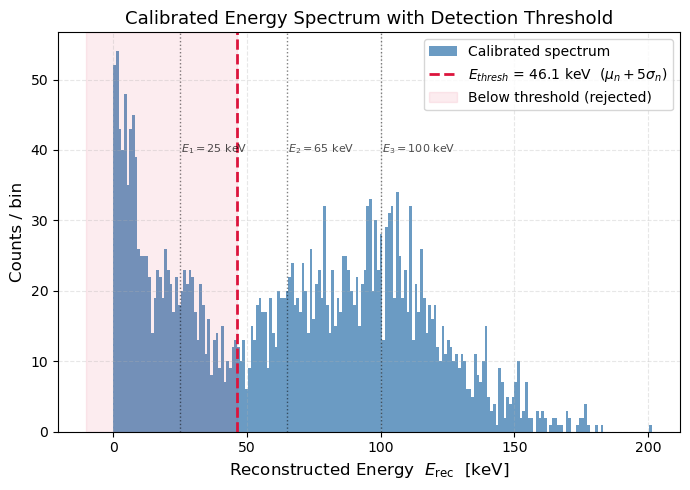


── Efficiency curve fit ─────────────────────────────────────────
  50% efficiency point : 46.02 ± 0.48 keV
  Turn-on width        : 8.17 ± 0.47 keV


In [204]:
# mf_amps, _ = optimal_filter_amp(all_data, template, psd_two, fs, coupling="AC")

# ─────────────────────────────────────────────────────────────────────────────
# Amplitude estimator
# ─────────────────────────────────────────────────────────────────────────────
# ── Peak estimator: maximum sample value ─────────────────────────────────────
window_end = min(pulse_peak_idx + int(3 * tau_fall * fs), trace_length)
# [data_area] = V·s, needs to be normalized by template_area (dim s)
data_area = np.sum(all_data[:, pulse_peak_idx:window_end], axis=1) * dt
template_area = np.sum(template[pulse_peak_idx:window_end]) * dt
int_amps = data_area / template_area

print("── Amplitude estimator ──────────────────────────────────────────")
print(f"Integral amps (noise)  mean : {int_amps[:300].mean():.3f} V")
print(f"Integral amps (pulses) mean : {int_amps[300:].mean():.3f} V")
print(f"Integral amps range         : {int_amps.min():.3f} → {int_amps.max():.3f} V")
print(int_amps.shape)

# ─────────────────────────────────────────────────────────────────────────────
# Fit the amplitude spectrum
# ─────────────────────────────────────────────────────────────────────────────
# ── 1. Fit the amplitude spectrum ─────────────────────────────────────────
result = fit_spectrum_curvefit(
    amplitudes  = int_amps,
    n_lines     = 4,          # 3 signal peaks + 1 noise blob
    mus_guess=(0,20,40,60),
    include_flat= True,       # flat random-trigger background
    bins        = 200,
)

# Unpack fit results (sorted by mu)
sort_idx = np.argsort(result['mus'])
mus      = result['mus'][sort_idx]
sigs     = result['sigs'][sort_idx]
areas    = result['areas'][sort_idx]
flatC    = result['flat_counts_per_bin']

centers      = result['bin_centers']
counts       = result['counts']
model_counts = result['model_counts']
edges        = result['bin_edges']
bw           = edges[1] - edges[0]

# Label components: noise blob = narrowest/lowest-mu; signal peaks = the rest
# (adjust labelling below if your histogram shows a different ordering)
noise_blob_idx = 0                      # lowest-amplitude Gaussian = noise blob
signal_idx     = [1, 2, 3]             # the three nuclear-decay lines

print("\n── Fit results ──────────────────────────────────────────────────")
labels = ['Noise blob', 'Peak A1', 'Peak A2', 'Peak A3']
for i, lab in enumerate(labels):
    print(f"  {lab:12s}  μ = {mus[i]:.4f} V   σ = {sigs[i]:.4f} V   area = {areas[i]:.1f}")
print(f"  Flat bkg      {flatC:.2f} counts/bin")

A1, A2, A3 = mus[1], mus[2], mus[3]
s1, s2, s3 = sigs[1], sigs[2], sigs[3]

# ─────────────────────────────────────────────────────────────────────────────
# Fit a, b and Inverse calibration
# ─────────────────────────────────────────────────────────────────────────────
# ── True energies of the three lines ─────────────────────────────────────────
E_true = np.array([25.0, 65.0, 100.0])   # keV

# ── Measured amplitudes from the MF fit (A1, A2, A3) ─────────────────────────
# These come from your fit_spectrum_curvefit result (sorted by mu)
A_meas = np.array([A1, A2, A3])           # V  — from previous step
A_err  = np.array([s1, s2, s3])           # V  — Gaussian widths as uncertainties
# A_err = [s1/np.sqrt(areas[1]), s2/np.sqrt(areas[2]), s3/np.sqrt(areas[3])]
# i.e. sigma_nll from the NLL scan

# ── 1. Fit saturation model  E_recon = a*(1 - exp(-E_true/b)) ────────────────
#    Rearranged: A_meas = a*(1 - exp(-E_true/b))
#    i.e. the measured amplitude IS E_recon in detector units

# Initial guesses: a ~ max amplitude, b ~ mid-range energy
p0 = [A_meas.max() * 1.2, 50.0]

popt, pcov = curve_fit(
    saturation_model,
    E_true, A_meas,
    p0     = p0,
    sigma  = A_err,
    absolute_sigma = True,
    maxfev = 10000
)
perr = np.sqrt(np.diag(pcov))

a_fit, b_fit = popt
a_err, b_err = perr

print(f"\n── Saturation model fit ─────────────────────────────────────────")
print(f"  a = {a_fit:.4f} ± {a_err:.4f}  (saturation amplitude)")
print(f"  b = {b_fit:.4f} ± {b_err:.4f}  (saturation energy scale [keV])")

# Goodness of fit
A_pred    = saturation_model(E_true, *popt)
residuals = A_meas - A_pred
chi2      = np.sum((residuals / A_err)**2)
print(f"  χ²/dof = {chi2:.3f} / {len(E_true)-2} = {chi2/(len(E_true)-2):.3f}")

# ── 2. Inverse calibration: A_meas → E_rec ───────────────────────────────────
# Invert  A = a*(1 - exp(-E/b))
#   E_rec = -b * ln(1 - A/a)

sig_E_int = np.zeros(3)
# for each peak — convert amplitude centre and width to energy resolution
print(f"\n── Inverse calibration check ────────────────────────────────────")
for i, (A, sig, lab) in enumerate(zip([A1, A2, A3], [s1, s2, s3], ['A1','A2','A3'])):
    E_centre  = inverse_calibration(A, a_fit, b_fit)
    sig_E     = sigma_energy(A, sig, a_fit, b_fit)
    sig_E_int[i] = sig_E
    print(f"  {lab}: E_true={E_true[i]:.1f} keV  "
          f"  A={A:.3f} V  "
          f"→  E_rec={E_centre:.2f} keV  "
          f"  σ_A={sig:.4f} V  "
          f"→  σ_E={sig_E:.4f} keV  "
          f"(resolution = {100*sig_E/E_centre:.2f}%)")

# ── 3. Convert full amplitude spectrum to energy spectrum ─────────────────────
# Filter to valid range (amplitudes must be < a_fit for log to be defined)
valid = (int_amps > 0) & (int_amps < a_fit * 0.999)
E_rec_all = inverse_calibration(int_amps[valid], a_fit, b_fit)

print(f"\n  Events converted: {valid.sum()} / {len(mf_amps)}")
print(f"  Energy range: {E_rec_all.min():.1f} – {E_rec_all.max():.1f} keV\n")

# ─────────────────────────────────────────────────────────────────────────────
# Energy threshold
# ─────────────────────────────────────────────────────────────────────────────
# ── noise blob parameters (index 0 after sorting) ─────────────────────────────
mu_n  = mus[0]    # centre of noise blob [V]
sig_n = sigs[0]   # width of noise blob  [V]

# detection threshold in amplitude space
A_thresh = mu_n + 5 * sig_n
print(f"── Detection threshold ──────────────────────────────────────────")
print(f"  μ_n        = {mu_n:.4f} V")
print(f"  σ_n        = {sig_n:.4f} V")
print(f"  A_thresh   = μ_n + 5σ_n = {A_thresh:.4f} V")

# ── 1. Convert threshold to energy via inverse calibration ────────────────────
E_thresh = inverse_calibration(A_thresh, a_fit, b_fit)
print(f"  E_thresh   = {E_thresh:.3f} keV  (after calibration)")

# ── 2. Plot calibrated energy spectrum with threshold marked ──────────────────
plt.figure(figsize=(7, 5))

# energy spectrum (only valid events)
plt.hist(E_rec_all, bins=200, color='steelblue', edgecolor='none',
         alpha=0.8, label='Calibrated spectrum')

# mark true line energies for reference
ymax = plt.ylim()[1]
for e, lab in zip(E_true, [r'$E_1=25$ keV', r'$E_2=65$ keV', r'$E_3=100$ keV']):
    plt.axvline(e, color='k', ls=':', lw=1.0, alpha=0.5)
    plt.text(e + 0.5, ymax * 0.7, lab, fontsize=8, color='k', alpha=0.7)

# threshold line
plt.axvline(E_thresh, color='crimson', lw=2, ls='--',
            label=f'$E_{{thresh}}$ = {E_thresh:.1f} keV  ($\\mu_n + 5\\sigma_n$)')

# shade the region below threshold (below-threshold / rejected region)
plt.axvspan(plt.xlim()[0], E_thresh, alpha=0.08, color='crimson',
            label='Below threshold (rejected)')

plt.xlabel('Reconstructed Energy  $E_\\mathrm{rec}$  [keV]', fontsize=12)
plt.ylabel('Counts / bin', fontsize=12)
plt.title('Calibrated Energy Spectrum with Detection Threshold', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Detection efficiency
# ─────────────────────────────────────────────────────────────────────────────
# ── Detection Efficiency via Pulse Injection ───────────────────────────────────

# energy grid to test — scan from well below to well above threshold
E_inject_grid = np.linspace(0, 150, 30)    # keV
n_inject_per_energy = 100                  # injected pulses per energy point
n_noise_traces = noise_data.shape[0]       # 300 noise traces available

efficiencies = np.zeros(len(E_inject_grid))

for ei, E_inj in enumerate(E_inject_grid):

    # convert true energy to expected amplitude using calibration
    A_inj = a_fit * (1.0 - np.exp(-E_inj / b_fit))   # [V]

    # inject into random noise traces
    n_detected = 0
    for j in range(n_inject_per_energy):
        # pick a random noise trace as the background
        noise_idx  = np.random.randint(0, n_noise_traces)
        noise_trace = noise_data[noise_idx]

        # inject: noise + scaled template
        injected_trace = noise_trace + A_inj * template
        
        # run amp estimator
        amp = np.sum(injected_trace[pulse_peak_idx:window_end]) * dt / template_area

        # convert amplitude to energy
        amp_clipped = np.clip(amp, 1e-9, a_fit * 0.999)
        E_rec_inj   = inverse_calibration(amp_clipped, a_fit, b_fit)
        #print(E_rec_inj)

        # detection criterion
        if E_rec_inj > E_thresh:
            n_detected += 1

    efficiencies[ei] = n_detected / n_inject_per_energy

# binomial uncertainty on efficiency
eff_err = np.sqrt(efficiencies * (1 - efficiencies) / n_inject_per_energy)
eff_err = np.where(eff_err == 0, 1/n_inject_per_energy, eff_err)  # avoid zero errors

try:
    popt_eff, pcov_eff = scipy_curve_fit(
        efficiency_model,
        E_inject_grid, efficiencies,
        p0     = [E_thresh, 5.0],
        sigma  = eff_err,
        absolute_sigma = True
    )
    E50_fit   = popt_eff[0]
    width_fit = popt_eff[1]
    perr_eff  = np.sqrt(np.diag(pcov_eff))
    print(f"\n── Efficiency curve fit ─────────────────────────────────────────")
    print(f"  50% efficiency point : {E50_fit:.2f} ± {perr_eff[0]:.2f} keV")
    print(f"  Turn-on width        : {width_fit:.2f} ± {perr_eff[1]:.2f} keV")
    fit_success = True
except Exception as e:
    print(f"  Efficiency fit failed: {e}")
    fit_success = False

E_thresh_int     = E_thresh
efficiencies_int = efficiencies.copy()
eff_err_int      = eff_err.copy()
popt_eff_int     = popt_eff.copy()
E50_int          = E50_fit
width_int        = width_fit


| Estimator      |   σ_E at 25 keV [keV] |   σ_E at 65 keV [keV] |   σ_E at 100 keV [keV] |   E_thresh [keV] |
|:---------------|----------------------:|----------------------:|-----------------------:|-----------------:|
| Matched Filter |                 9.403 |                10.761 |                 15.891 |            32.04 |
| Peak           |                 3.613 |                33.274 |                 12.529 |            29.35 |
| Integral       |                 9.044 |                12.663 |                 21.016 |            46.09 |


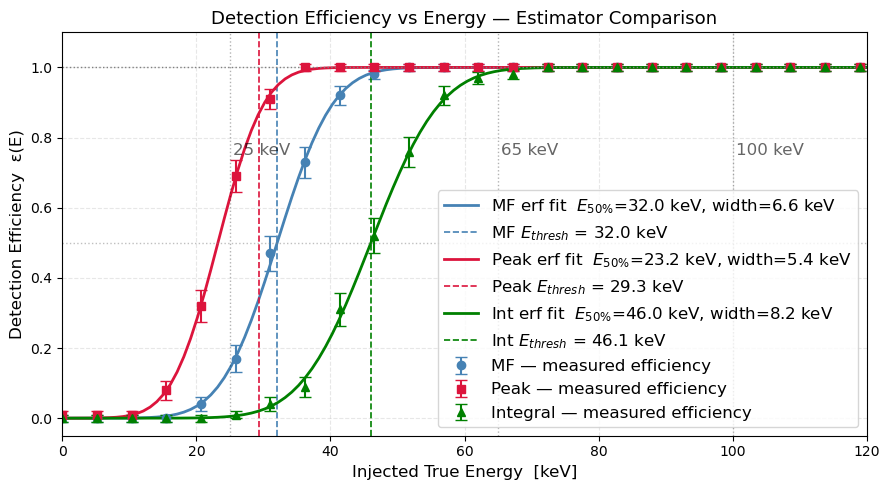

In [205]:
# ── Build summary table ───────────────────────────────────────────────────────
df = pd.DataFrame({
    'Estimator': ['Matched Filter', 'Peak', 'Integral'],
    'σ_E at 25 keV [keV]': [f'{sig_E_mf[0]:.3f}',
                              f'{sig_E_peak[0]:.3f}',
                              f'{sig_E_int[0]:.3f}'],
    'σ_E at 65 keV [keV]': [f'{sig_E_mf[1]:.3f}',
                              f'{sig_E_peak[1]:.3f}',
                              f'{sig_E_int[1]:.3f}'],
    'σ_E at 100 keV [keV]': [f'{sig_E_mf[2]:.3f}',
                               f'{sig_E_peak[2]:.3f}',
                               f'{sig_E_int[2]:.3f}'],
    'E_thresh [keV]': [f'{E_thresh_mf:.2f}',
                        f'{E_thresh_peak:.2f}',
                        f'{E_thresh_int:.2f}'],
})

print(df.to_markdown(index=False))



E_inject_grid = np.linspace(0, 150, 30)
E_fine = np.linspace(0, 150, 150)

plt.figure(figsize=(9, 5))

# ── MF estimator ──────────────────────────────────────────────────────────────
plt.errorbar(E_inject_grid, efficiencies_mf, yerr=eff_err_mf,
             fmt='o', color='steelblue', capsize=4, ms=6,
             label='MF — measured efficiency')
plt.plot(E_fine, efficiency_model(E_fine, *popt_eff_mf),
         color='steelblue', lw=2,
         label=f'MF erf fit  $E_{{50\\%}}$={E50_mf:.1f} keV, width={width_mf:.1f} keV')
plt.axvline(E_thresh_mf, color='steelblue', ls='--', lw=1.2,
            label=f'MF $E_{{thresh}}$ = {E_thresh_mf:.1f} keV')

# ── Peak estimator ────────────────────────────────────────────────────────────
plt.errorbar(E_inject_grid, efficiencies_peak, yerr=eff_err_peak,
             fmt='s', color='crimson', capsize=4, ms=6,
             label='Peak — measured efficiency')
plt.plot(E_fine, efficiency_model(E_fine, *popt_eff_peak),
         color='crimson', lw=2,
         label=f'Peak erf fit  $E_{{50\\%}}$={E50_peak:.1f} keV, width={width_peak:.1f} keV')
plt.axvline(E_thresh_peak, color='crimson', ls='--', lw=1.2,
            label=f'Peak $E_{{thresh}}$ = {E_thresh_peak:.1f} keV')

# ── Integral estimator ────────────────────────────────────────────────────────
plt.errorbar(E_inject_grid, efficiencies_int, yerr=eff_err_int,
             fmt='^', color='green', capsize=4, ms=6,
             label='Integral — measured efficiency')
plt.plot(E_fine, efficiency_model(E_fine, *popt_eff_int),
         color='green', lw=2,
         label=f'Int erf fit  $E_{{50\\%}}$={E50_int:.1f} keV, width={width_int:.1f} keV')
plt.axvline(E_thresh_int, color='green', ls='--', lw=1.2,
            label=f'Int $E_{{thresh}}$ = {E_thresh_int:.1f} keV')

# ── Reference lines and true energies ────────────────────────────────────────
plt.axhline(1.0, color='gray', ls=':', lw=1)
plt.axhline(0.5, color='gray', ls=':', lw=1, alpha=0.5)
for e, lab in zip(E_true, ['25 keV', '65 keV', '100 keV']):
    plt.axvline(e, color='k', ls=':', lw=1.0, alpha=0.3)
    plt.text(e + 0.5, 0.75, lab, fontsize=12, color='k', alpha=0.6)

plt.xlabel('Injected True Energy  [keV]', fontsize=12)
plt.ylabel('Detection Efficiency  ε(E)', fontsize=12)
plt.title('Detection Efficiency vs Energy — Estimator Comparison', fontsize=13)
plt.xlim(0, 120)
plt.ylim(-0.05, 1.1)
plt.legend(fontsize=12, bbox_to_anchor=(1, 0), loc='lower right')
plt.grid(True, ls='--', alpha=0.3)
plt.tight_layout()
# plt.savefig('efficiency_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### Diagnostic

Pulse peak index  — mean: 2057.0, std: 590.6, median: 2051
Template peak index: 2053

Pulse data amplitude range  : -30.348 → 113.363 V
Noise data amplitude range  : -27.820 → 29.474 V
Template amplitude range    : 0.0000 → 1.0000 V

Mean peak amplitude (pulses): 48.866 V
MF amps (noise)  mean : 0.023 V
MF amps (pulses) mean : 20.492 V


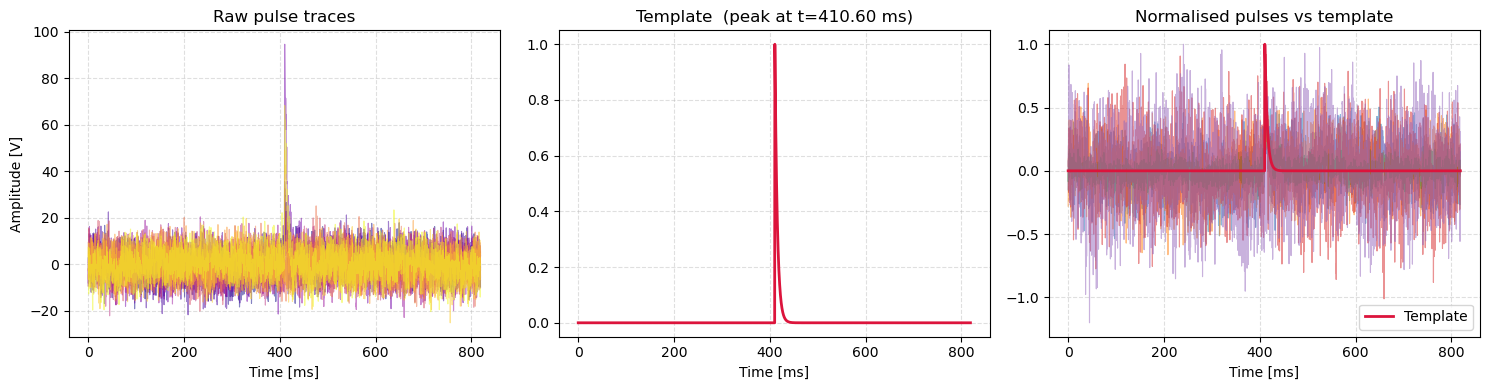


Template peak time : 410.600 ms
Pulse peak time    : 411.406 ± 118.116 ms

  Template and pulse peaks are well aligned


In [206]:
# ── Diagnostic 1: check where pulses actually peak ────────────────────────────
peak_indices = np.argmax(pulse_data, axis=1)
print(f"Pulse peak index  — mean: {peak_indices.mean():.1f}, "
      f"std: {peak_indices.std():.1f}, "
      f"median: {np.median(peak_indices):.0f}")
print(f"Template peak index: {np.argmax(template)}")

# ── Diagnostic 2: check amplitude scales ──────────────────────────────────────
print(f"\nPulse data amplitude range  : {pulse_data.min():.3f} → {pulse_data.max():.3f} V")
print(f"Noise data amplitude range  : {noise_data.min():.3f} → {noise_data.max():.3f} V")
print(f"Template amplitude range    : {template.min():.4f} → {template.max():.4f} V")
print(f"\nMean peak amplitude (pulses): {pulse_data.max(axis=1).mean():.3f} V")
print(f"MF amps (noise)  mean : {mf_amps[:300].mean():.3f} V")
print(f"MF amps (pulses) mean : {mf_amps[300:].mean():.3f} V")

# ── Diagnostic 3: plot template vs a few real pulses overlaid ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# raw pulse traces
ax = axes[0]
colors = plt.get_cmap("plasma")(np.linspace(0, 1, 10))
for ii in range(10):
    ax.plot(time * 1e3, pulse_data[ii], c=colors[ii % len(colors)],
            alpha=0.5, lw=0.8)
ax.set_title('Raw pulse traces')
ax.set_xlabel('Time [ms]')
ax.set_ylabel('Amplitude [V]')
ax.grid(True, ls='--', alpha=0.4)

# template alone
ax = axes[1]
ax.plot(time * 1e3, template, color='crimson', lw=2)
ax.set_title(f'Template  (peak at t={time[np.argmax(template)]*1e3:.2f} ms)')
ax.set_xlabel('Time [ms]')
ax.grid(True, ls='--', alpha=0.4)

# overlay: normalised pulse vs template
ax = axes[2]
for ii in range(5):
    p = pulse_data[ii]
    p_norm = p / p.max()
    ax.plot(time * 1e3, p_norm, alpha=0.5, lw=0.8)
ax.plot(time * 1e3, template, color='crimson', lw=2, label='Template')
ax.set_title('Normalised pulses vs template')
ax.set_xlabel('Time [ms]')
ax.legend()
ax.grid(True, ls='--', alpha=0.4)

plt.tight_layout()
# plt.savefig('diagnostics.png', dpi=150)
plt.show()

# ── Diagnostic 4: check if pulse peak aligns with template peak ───────────────
template_peak_time = time[np.argmax(template)] * 1e3
pulse_peak_times   = time[peak_indices] * 1e3
print(f"\nTemplate peak time : {template_peak_time:.3f} ms")
print(f"Pulse peak time    : {pulse_peak_times.mean():.3f} ± "
      f"{pulse_peak_times.std():.3f} ms")

if abs(template_peak_time - pulse_peak_times.mean()) > 1:
    print("\n  WARNING: template and pulse peaks are misaligned!")
    print("  → Fix: shift template to match pulse peak position")
else:
    print("\n  Template and pulse peaks are well aligned")
